# Conditional VAE 实现 - CIFAR-10

## 条件变分自编码器（Conditional VAE）原理

条件变分自编码器（Conditional Variational Autoencoder, CVAE）是变分自编码器（VAE）的扩展，它允许根据额外的条件信息（如类别标签）生成和操控数据。CVAE 由 Kihyuk Sohn、Honglak Lee 和 Xinchen Yan 等人在2015年提出，为生成模型增加了条件控制能力。

### CVAE的基本思想

标准VAE通过编码器将输入数据映射到潜在空间的概率分布，再通过解码器从该分布中采样并重建数据。CVAE在此基础上引入了条件信息，使得：

- **编码器**：同时考虑输入数据和条件信息，生成条件潜在分布
- **解码器**：同时使用潜在向量和条件信息，重建或生成符合条件的数据

这种条件机制使得CVAE能够学习条件数据分布，并在测试/生成阶段通过改变条件来控制生成结果的属性。

### CVAE的数学表达

#### 概率模型

设：
- $x$：输入数据（如图像）
- $y$：条件信息（如类别标签）
- $z$：潜在变量

CVAE试图最大化条件对数似然 $\log p(x|y)$，由于直接优化困难，我们引入变分推断方法。

#### CVAE的目标函数：条件证据下界（ELBO）

CVAE的训练目标是最大化条件证据下界（Conditional Evidence Lower Bound）：

$$\log p(x|y) \geq \mathbb{E}_{z \sim q_{\phi}(z|x,y)} \left[ \log p_{\theta}(x|z,y) \right] - D_{KL} \left( q_{\phi}(z|x,y) \| p_{\theta}(z|y) \right)$$

其中：
- $q_{\phi}(z|x,y)$：由编码器网络参数化的近似后验分布
- $p_{\theta}(x|z,y)$：由解码器网络参数化的条件似然
- $p_{\theta}(z|y)$：条件先验分布

这个目标函数可分解为两部分：

1. **条件重建项** $\mathbb{E}_{z \sim q_{\phi}(z|x,y)} \left[ \log p_{\theta}(x|z,y) \right]$：
   - 衡量从条件潜在变量重建原始数据的质量
   - 通常使用均方误差（MSE）或交叉熵实现

2. **条件KL散度项** $D_{KL} \left( q_{\phi}(z|x,y) \| p_{\theta}(z|y) \right)$：
   - 衡量近似后验分布 $q_{\phi}(z|x,y)$ 与条件先验分布 $p_{\theta}(z|y)$ 之间的差异
   - 作为正则化项，防止编码器产生过于复杂的分布

### 简化假设

在实践中，通常做如下假设：

- 条件先验分布 $p_{\theta}(z|y)$ 简化为标准正态分布 $\mathcal{N}(0, I)$，即假设条件 $y$ 不影响先验
- 近似后验分布 $q_{\phi}(z|x,y)$ 设为对角高斯分布 $\mathcal{N}(\mu_{\phi}(x,y), \text{diag}(\sigma^2_{\phi}(x,y)))$
- 条件似然 $p_{\theta}(x|z,y)$ 通常假设为高斯分布（连续数据）或伯努利分布（二元数据）

在这些假设下，KL散度项有解析解：

$$D_{KL} \left( q_{\phi}(z|x,y) \| p_{\theta}(z|y) \right) = \frac{1}{2} \sum_{j=1}^{J} \left( 1 + \log(\sigma^2_j) - \mu^2_j - \sigma^2_j \right)$$

其中 $J$ 是潜在空间的维度，$\mu_j$ 和 $\sigma^2_j$ 是 $q_{\phi}(z|x,y)$ 的均值和方差。

## CVAE的结构设计

CVAE的条件信息可以通过多种方式融入到模型中：

1. **连接（Concatenation）**：
   - 在编码器中，将条件信息与输入数据连接，共同输入网络
   - 在解码器中，将条件信息与潜在向量连接，共同参与重建

2. **条件层（Conditional Layers）**：
   - 使用条件批归一化（Conditional Batch Normalization）
   - 或其他条件层处理方式，如条件实例归一化

3. **独立条件先验**：
   - 为不同条件建立不同的先验分布
   - 这需要学习条件相关的先验参数

本实现中，我们采用了连接（Concatenation）的方式，将类别信息通过one-hot编码后与特征或潜在向量连接。

## 重参数化技巧与KL退火

与VAE类似，CVAE也使用重参数化技巧使采样过程可微：

$$z = \mu_{\phi}(x,y) + \sigma_{\phi}(x,y) \odot \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, I)$$

其中 $\odot$ 表示元素级乘法。

为了平衡重建质量和KL散度，常使用KL退火（KL annealing）技术，即在训练初期使用较小的KL散度权重，随训练进行逐渐增大至目标值。这有助于模型先学习有效的重建，再逐步规范潜在空间分布。

## CVAE的优势与应用

与标准VAE相比，CVAE具有以下优势：

1. **条件控制**：能够根据指定条件生成相应数据
2. **条件一致性**：同一潜在向量在不同条件下可产生不同但语义相关的输出
3. **类别特化**：针对不同类别学习专门的生成分布
4. **多样性维持**：在条件相同的情况下，通过不同潜在向量实现生成多样性

CVAE广泛应用于图像生成、图像转换、风格迁移、文本条件图像生成等任务。在本实现中，我们将其应用于CIFAR-10图像数据集，实现类别条件的图像生成。

## 环境设置

In [ ]:
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

MODEL_SAVE_PATH = "../model/conditional_vae"
RESULT_SAVE_PATH = "../result/conditional_vae"

Path(MODEL_SAVE_PATH).mkdir(parents=True, exist_ok=True)
Path(RESULT_SAVE_PATH).mkdir(parents=True, exist_ok=True)

Using device: mps


## 超参数设置

条件变分自编码器（CVAE）的性能很大程度上依赖于超参数的选择，这些参数影响网络结构、训练过程和生成效果：

- `batch_size`: 每批训练的样本数量，影响训练效率和稳定性
- `image_size`: 输入图像的尺寸，CIFAR-10为32x32像素
- `nc`: 图像通道数，彩色图像为3通道(RGB)
- `latent_dim`: 潜在向量的维度，影响模型的表达能力和生成多样性
- `hidden_dim`: 中间层的维度，控制网络容量
- `num_classes`: 条件类别的数量，CIFAR-10包含10个类别
- `num_epochs`: 训练的总轮数
- `learning_rate`: 优化器学习率，影响收敛速度和稳定性

与普通VAE相比，CVAE额外考虑了条件信息的嵌入方式和融合策略，这为生成过程提供了额外的可控性，但也增加了模型复杂度。

In [ ]:
batch_size = 256
image_size = 32
nc = 3  # 图像通道数 (RGB)
latent_dim = 128  # 潜在向量z的维度
hidden_dim = 256  # 隐藏层维度
num_classes = 10  # CIFAR-10类别数量
num_epochs = 100  # 训练轮数
learning_rate = 1e-3  # 学习率

## 数据加载与预处理

In [ ]:
# 数据预处理：转换为张量
transform = transforms.Compose([
    transforms.ToTensor(),  # 将图像从[0,255]转换为[0,1]范围的张量
])

# 加载CIFAR-10数据集
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

## 条件变分自编码器模型结构

CVAE结合了条件信息和变分推断，其网络架构由三个关键部分组成：编码器、重参数化层和解码器。以下是本实现中CVAE模型的详细设计：

### 编码器结构

编码器负责将输入图像和类别标签映射到潜在空间的分布参数（均值和方差）：

1. **图像处理路径**：
   - 使用多层卷积网络逐步降低图像分辨率，增加特征深度
   - 每层使用批归一化和ReLU激活函数增强特征提取能力
   - 最终将图像特征展平为一维向量

2. **条件信息融合**：
   - 将类别标签转换为one-hot编码
   - 将one-hot向量与展平的图像特征连接
   - 通过全连接层处理融合后的特征

3. **潜在分布参数**：
   - 使用两个独立的全连接层分别输出均值(μ)和对数方差(log σ²)

### 解码器结构

解码器将采样的潜在向量和类别标签映射回图像空间：

1. **条件信息融合**：
   - 将类别的one-hot编码与潜在向量连接
   - 通过全连接层处理融合后的向量

2. **特征重建**：
   - 使用全连接层将向量映射到合适的特征维度
   - 重塑特征为三维张量，以适应转置卷积输入

3. **图像生成**：
   - 使用多层转置卷积逐步增加分辨率
   - 每层使用批归一化和ReLU激活函数
   - 最后一层使用Sigmoid激活函数将输出约束在[0,1]范围

这种架构设计使CVAE能够学习条件数据分布，并在测试阶段通过指定不同的类别标签来控制生成内容。

In [ ]:
class CVAE(nn.Module):
    """
    条件变分自编码器(CVAE)模型
    
    将图像和类别标签编码到潜在空间，并能从潜在空间和类别标签重建/生成图像
    """
    def __init__(self, latent_dim=128, num_classes=10):
        """
        初始化CVAE模型
        
        Args:
            latent_dim: 潜在空间的维度
            num_classes: 类别数量
        """
        super(CVAE, self).__init__()
        
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        
        # 编码器卷积层
        self.enc_conv1 = nn.Conv2d(nc, 32, kernel_size=4, stride=2, padding=1)  # 32x16x16
        self.enc_conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 64x8x8
        self.enc_conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1)  # 128x4x4
        
        # 计算展平后的特征大小
        self.flatten_size = 128 * 4 * 4
        
        # 处理展平图像特征和类别标签的全连接层
        self.enc_fc1 = nn.Linear(self.flatten_size + num_classes, hidden_dim)
        
        # 潜在分布的均值和方差参数
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)
        
        # 解码器的初始全连接层
        self.dec_fc1 = nn.Linear(latent_dim + num_classes, hidden_dim)
        self.dec_fc2 = nn.Linear(hidden_dim, self.flatten_size)
        
        # 解码器反卷积层
        self.dec_conv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 64x8x8
        self.dec_conv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 32x16x16
        self.dec_conv3 = nn.ConvTranspose2d(32, nc, kernel_size=4, stride=2, padding=1)  # 3x32x32
        
        # 批归一化层
        self.enc_bn1 = nn.BatchNorm2d(32)
        self.enc_bn2 = nn.BatchNorm2d(64)
        self.enc_bn3 = nn.BatchNorm2d(128)
        
        self.dec_bn1 = nn.BatchNorm2d(64)
        self.dec_bn2 = nn.BatchNorm2d(32)
        
    def encode(self, x, c):
        """
        将输入图像和类别标签编码为潜在分布参数
        
        Args:
            x: 输入图像，形状为 [batch_size, channels, height, width]
            c: 类别标签的one-hot编码，形状为 [batch_size, num_classes]
            
        Returns:
            mu, log_var: 潜在分布的均值和对数方差
        """
        # 通过卷积层处理图像
        x = F.relu(self.enc_bn1(self.enc_conv1(x)))
        x = F.relu(self.enc_bn2(self.enc_conv2(x)))
        x = F.relu(self.enc_bn3(self.enc_conv3(x)))
        
        # 展平卷积输出
        x = x.view(-1, self.flatten_size)
        
        # 与one-hot类别标签连接
        x = torch.cat([x, c], dim=1)
        
        # 通过全连接层处理
        x = F.relu(self.enc_fc1(x))
        
        # 获取潜在分布参数
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """
        重参数化技巧，使采样过程可微
        
        Args:
            mu: 潜在分布的均值
            log_var: 潜在分布的对数方差
            
        Returns:
            z: 采样的潜在向量
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z
    
    def decode(self, z, c):
        """
        从潜在向量和类别标签解码生成图像
        
        Args:
            z: 潜在向量，形状为 [batch_size, latent_dim]
            c: 类别标签的one-hot编码，形状为 [batch_size, num_classes]
            
        Returns:
            x_reconstructed: 重建/生成的图像
        """
        # 将潜在向量与one-hot类别标签连接
        z = torch.cat([z, c], dim=1)
        
        # 通过全连接层处理
        x = F.relu(self.dec_fc1(z))
        x = F.relu(self.dec_fc2(x))
        
        # 重塑为适合反卷积层的形状
        x = x.view(-1, 128, 4, 4)
        
        # 通过反卷积层处理
        x = F.relu(self.dec_bn1(self.dec_conv1(x)))
        x = F.relu(self.dec_bn2(self.dec_conv2(x)))
        x = torch.sigmoid(self.dec_conv3(x))  # 使用sigmoid确保输出在[0,1]范围内
        
        return x
    
    def forward(self, x, c):
        """
        CVAE的前向传播
        
        Args:
            x: 输入图像，形状为 [batch_size, channels, height, width]
            c: 类别索引，形状为 [batch_size]
            
        Returns:
            x_reconstructed, mu, log_var: 重建图像和潜在分布参数
        """
        # 将类别索引转换为one-hot向量
        c_one_hot = F.one_hot(c, num_classes=self.num_classes).float()
        
        # 编码、采样和解码
        mu, log_var = self.encode(x, c_one_hot)
        z = self.reparameterize(mu, log_var)
        x_reconstructed = self.decode(z, c_one_hot)
        
        return x_reconstructed, mu, log_var

## CVAE损失函数与KL退火策略

CVAE的训练目标是最大化条件证据下界（ELBO），其损失函数由重建损失和KL散度两部分组成：

### 损失函数组成

1. **重建损失**：衡量原始图像和重建图像之间的差异，在本实现中使用均方误差（MSE）：

   $$\mathcal{L}_{\text{recon}} = \frac{1}{N} \sum_{i=1}^{N} \|x_i - \hat{x}_i\|^2$$

   其中 $x_i$ 是原始图像，$\hat{x}_i$ 是重建图像，$N$ 是批量大小。

2. **KL散度损失**：衡量近似后验分布与先验分布的差异，起正则化作用：

   $$\mathcal{L}_{\text{KL}} = -\frac{1}{2} \sum_{j=1}^{J} (1 + \log\sigma^2_j - \mu^2_j - \sigma^2_j)$$

   其中 $J$ 是潜在空间维度，$\mu_j$ 和 $\sigma^2_j$ 是潜在分布的均值和方差。

3. **总损失**：两部分损失的加权和，应用了KL退火权重：

   $$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{recon}} + \lambda \cdot \mathcal{L}_{\text{KL}}$$

   其中 $\lambda$ 是KL散度的权重系数，由KL退火策略确定。

### KL退火策略

KL退火（KL annealing）是一种训练技巧，通过逐步增加KL散度项的权重来平衡重建质量和潜在空间正则化：

1. **初始阶段（低权重）**：
   - 模型首先集中于学习有效的重建
   - KL散度权重接近于0，减轻对潜在空间的约束

2. **过渡阶段（权重增加）**：
   - 随着训练进行，KL权重线性或非线性增加
   - 逐步引入潜在空间的正则化

3. **最终阶段（目标权重）**：
   - KL权重达到预设的目标值（通常为1.0）
   - 模型同时优化重建质量和潜在空间结构

这种策略有助于避免"KL散度消失"问题（即模型忽略潜在空间，导致条件控制失效），同时确保良好的重建质量。在本实现中，我们使用线性退火策略，在前15个epoch内将KL权重从0逐渐增加到1。

In [ ]:
def loss_function(recon_x, x, mu, log_var, kld_weight=1.0):
    """
    计算CVAE的损失函数：重建损失 + KL散度
    
    Args:
        recon_x: 重建的图像
        x: 原始图像
        mu: 潜在分布的均值
        log_var: 潜在分布的对数方差
        kld_weight: KL散度项的权重系数
        
    Returns:
        total_loss: 总损失
        recon_loss: 重建损失
        kl_div: KL散度损失
    """
    # Reconstruction loss: mean squared error
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    
    # KL divergence: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    
    # Total loss with weighting
    total_loss = recon_loss + kld_weight * kl_div
    
    return total_loss, recon_loss, kl_div

In [6]:
model = CVAE(latent_dim=latent_dim, num_classes=num_classes).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [7]:
model

CVAE(
  (enc_conv1): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_conv3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_fc1): Linear(in_features=2058, out_features=256, bias=True)
  (fc_mu): Linear(in_features=256, out_features=128, bias=True)
  (fc_log_var): Linear(in_features=256, out_features=128, bias=True)
  (dec_fc1): Linear(in_features=138, out_features=256, bias=True)
  (dec_fc2): Linear(in_features=256, out_features=2048, bias=True)
  (dec_conv1): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (dec_conv3): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (enc_bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (enc_bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, a

In [ ]:
def kl_annealing_weight(epoch, start_weight=0.0, end_weight=1.0, annealing_epochs=10):
    """
    计算KL退火权重
    
    Args:
        epoch: 当前训练轮数
        start_weight: 起始权重
        end_weight: 目标权重
        annealing_epochs: 退火过程的轮数
    
    Returns:
        weight: 当前轮数的KL散度权重
    """
    if epoch >= annealing_epochs:
        return end_weight
    return start_weight + (end_weight - start_weight) * epoch / annealing_epochs

## 训练与评估

CVAE的训练过程包括前向传播、损失计算、反向传播和参数更新。为了监控训练进展和评估模型性能，我们实现了多种功能：

### 训练函数

训练函数负责一个完整epoch的模型训练，包括批次迭代、损失计算和参数更新。使用进度条显示实时训练状态，并返回平均损失值供后续分析。

### 条件生成与可视化

为了评估CVAE的条件生成能力，我们实现了多种生成和可视化函数：

1. **类别条件生成**：
   - 从标准正态分布采样潜在向量
   - 为这些向量指定特定的类别标签
   - 生成符合指定类别的图像

2. **条件控制展示**：
   - 使用相同的潜在向量，但指定不同的类别标签
   - 观察相同潜在内容在不同类别条件下的表现差异

3. **重建质量评估**：
   - 将真实图像输入模型进行重建
   - 比较原始图像和重建图像，评估模型保留信息的能力

这些评估不仅帮助我们理解模型的学习情况，也展示了CVAE的独特优势：能够根据条件控制生成内容，同时保持潜在空间的连续性和结构化特性。

In [ ]:
def train(epoch, kld_weight):
    """
    训练模型一个epoch
    
    Args:
        epoch: 当前训练轮数
        kld_weight: 当前KL散度权重
        
    Returns:
        avg_loss: 平均总损失
        avg_recon_loss: 平均重建损失
        avg_kl_loss: 平均KL散度损失
    """
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0
    
    # Create progress bar
    pbar = tqdm(enumerate(train_loader), total=len(train_loader),
                desc=f"Epoch {epoch}/{num_epochs}")
    
    for batch_idx, (data, target) in pbar:
        data, target = data.to(device), target.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        recon_batch, mu, log_var = model(data, target)
        loss, recon_loss, kl_loss = loss_function(recon_batch, data, mu, log_var, kld_weight)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kl_loss_total += kl_loss.item()
        
        # Update progress bar with current loss values
        batch_size = data.size(0)
        pbar.set_postfix({
            'Loss': f'{loss.item() / batch_size:.6f}',
            'Recon': f'{recon_loss.item() / batch_size:.6f}',
            'KL': f'{kl_loss.item() / batch_size:.6f}',
            'KLD Weight': f'{kld_weight:.4f}'
        })
    
    # Return average losses for the epoch
    avg_loss = train_loss / len(train_loader.dataset)
    avg_recon_loss = recon_loss_total / len(train_loader.dataset)
    avg_kl_loss = kl_loss_total / len(train_loader.dataset)
    
    print(f'====> Epoch: {epoch} Average loss: {avg_loss:.6f} '
          f'Average Reconstruction Loss: {avg_recon_loss:.6f} '
          f'Average KL Loss: {avg_kl_loss:.6f} '
          f'KLD Weight: {kld_weight:.4f}')
    
    return avg_loss, avg_recon_loss, avg_kl_loss

# Generate conditional samples
def generate_conditional_samples(model, class_idx=None):
    """
    生成条件样本图像
    
    Args:
        model: 训练好的CVAE模型
        class_idx: 指定的类别索引（None表示生成所有类别）
        
    Returns:
        samples: 生成的图像
        labels: 对应的类别标签
    """
    model.eval()
    with torch.no_grad():
        if class_idx is not None:
            # Generate samples for a specific class
            samples_per_class = 10
            z = torch.randn(samples_per_class, latent_dim).to(device)
            labels = torch.full((samples_per_class,), class_idx).to(device)
            c_one_hot = F.one_hot(labels, num_classes=num_classes).float()
            samples = model.decode(z, c_one_hot).cpu()
            
            return samples, labels.cpu()
        else:
            # Generate samples for all classes
            samples_per_class = 10
            total_samples = samples_per_class * num_classes
            z = torch.randn(total_samples, latent_dim).to(device)
            labels = torch.cat([torch.full((samples_per_class,), i) for i in range(num_classes)]).to(device)
            c_one_hot = F.one_hot(labels, num_classes=num_classes).float()
            samples = model.decode(z, c_one_hot).cpu()
            
            return samples, labels.cpu()

# Display function for generated images
def display_samples(samples, labels, class_names=None, save_path=None):
    """
    以网格形式显示生成的样本
    
    Args:
        samples: 生成的图像
        labels: 对应的类别标签
        class_names: 类别名称列表
        save_path: 图像保存路径
    """
    if class_names is None:
        class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                      'dog', 'frog', 'horse', 'ship', 'truck']
    
    samples_per_class = 10
    num_classes = len(class_names)
    fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 15))
    
    for i in range(num_classes):
        for j in range(samples_per_class):
            idx = i * samples_per_class + j
            if idx < len(samples):
                ax = axes[i, j]
                ax.imshow(samples[idx].permute(1, 2, 0).numpy())
                if j == 0:  # Add class label on the left
                    ax.set_ylabel(class_names[i])
                ax.axis('off')
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path)
    plt.show()


Epoch 1/100: 100%|██████████| 196/196 [00:16<00:00, 11.76it/s, Loss=72.396783, Recon=72.396783, KL=1621.631934, KLD Weight=0.0000] 

====> Epoch: 1 Average loss: 102.389989 Average Reconstruction Loss: 102.389989 Average KL Loss: 2163.439024 KLD Weight: 0.0000
New best model saved at epoch 1 with loss: 102.389989



Epoch 2/100: 100%|██████████| 196/196 [00:14<00:00, 13.21it/s, Loss=65.344202, Recon=59.910907, KL=81.499463, KLD Weight=0.0667] 

====> Epoch: 2 Average loss: 79.497515 Average Reconstruction Loss: 72.486923 Average KL Loss: 105.158861 KLD Weight: 0.0667
New best model saved at epoch 2 with loss: 79.497515



Epoch 3/100: 100%|██████████| 196/196 [00:16<00:00, 11.69it/s, Loss=61.069629, Recon=52.813464, KL=61.921216, KLD Weight=0.1333]

...

====> Epoch: 8 Average loss: 64.118675 Average Reconstruction Loss: 48.995809 Average KL Loss: 32.406140 KLD Weight: 0.4667



Epoch 9/100: 100%|██████████| 196/196 [00:18<00:00, 10.37it/s, Loss=65.558502, Recon=49.068536, KL=30.918683, KLD Weight=0.5333]

====> Epoch: 9 Average loss: 65.549555 Average Reconstruction Loss: 49.298960 Average KL Loss: 30.469864 KLD Weight: 0.5333



Epoch 10/100: 100%|██████████| 196/196 [00:13<00:00, 15.04it/s, Loss=69.405591, Recon=52.356775, KL=28.414697, KLD Weight=0.6000]


====> Epoch: 10 Average loss: 66.925861 Average Reconstruction Loss: 49.671160 Average KL Loss: 28.757833 KLD Weight: 0.6000
Model saved to ../model/conditional_vae/cvae_epoch_10.pth


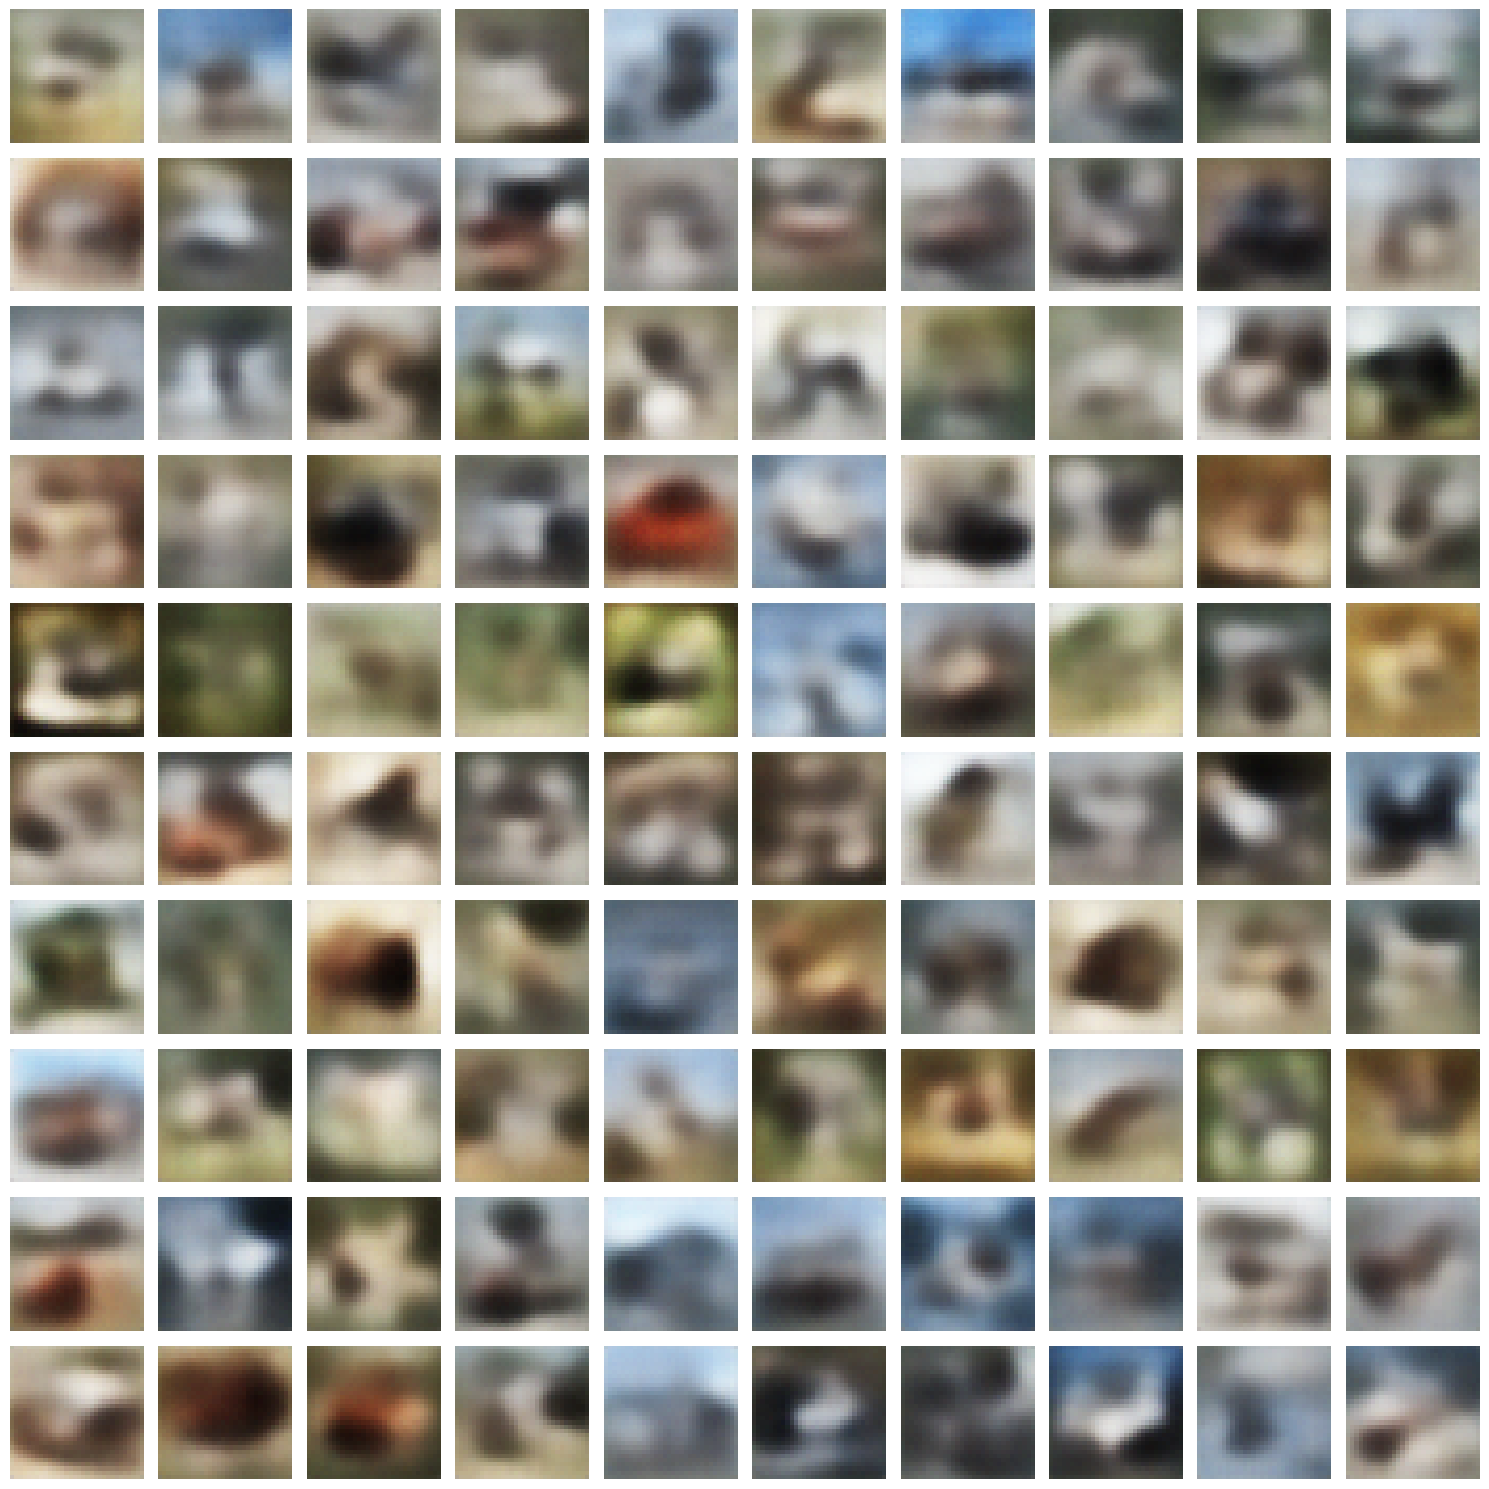

Samples saved to ../result/conditional_vae/cvae_samples_epoch_10.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_10.png


Epoch 11/100: 100%|██████████| 196/196 [00:15<00:00, 12.46it/s, Loss=70.047168, Recon=51.833557, KL=27.320413, KLD Weight=0.6667]

====> Epoch: 11 Average loss: 68.450568 Average Reconstruction Loss: 50.304050 Average KL Loss: 27.219777 KLD Weight: 0.6667



Epoch 12/100: 100%|██████████| 196/196 [00:19<00:00, 10.17it/s, Loss=73.046191, Recon=53.710358, KL=26.367050, KLD Weight=0.7333]

====> Epoch: 12 Average loss: 69.757101 Average Reconstruction Loss: 50.847604 Average KL Loss: 25.785678 KLD Weight: 0.7333


...

====> Epoch: 18 Average loss: 74.792103 Average Reconstruction Loss: 53.760130 Average KL Loss: 21.031973 KLD Weight: 1.0000



Epoch 19/100: 100%|██████████| 196/196 [00:15<00:00, 12.83it/s, Loss=71.831616, Recon=52.208228, KL=19.623390, KLD Weight=1.0000]

====> Epoch: 19 Average loss: 74.679430 Average Reconstruction Loss: 53.700871 Average KL Loss: 20.978559 KLD Weight: 1.0000



Epoch 20/100: 100%|██████████| 196/196 [00:15<00:00, 12.54it/s, Loss=72.352612, Recon=50.203098, KL=22.149518, KLD Weight=1.0000]


====> Epoch: 20 Average loss: 74.567540 Average Reconstruction Loss: 53.619170 Average KL Loss: 20.948370 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_20.pth


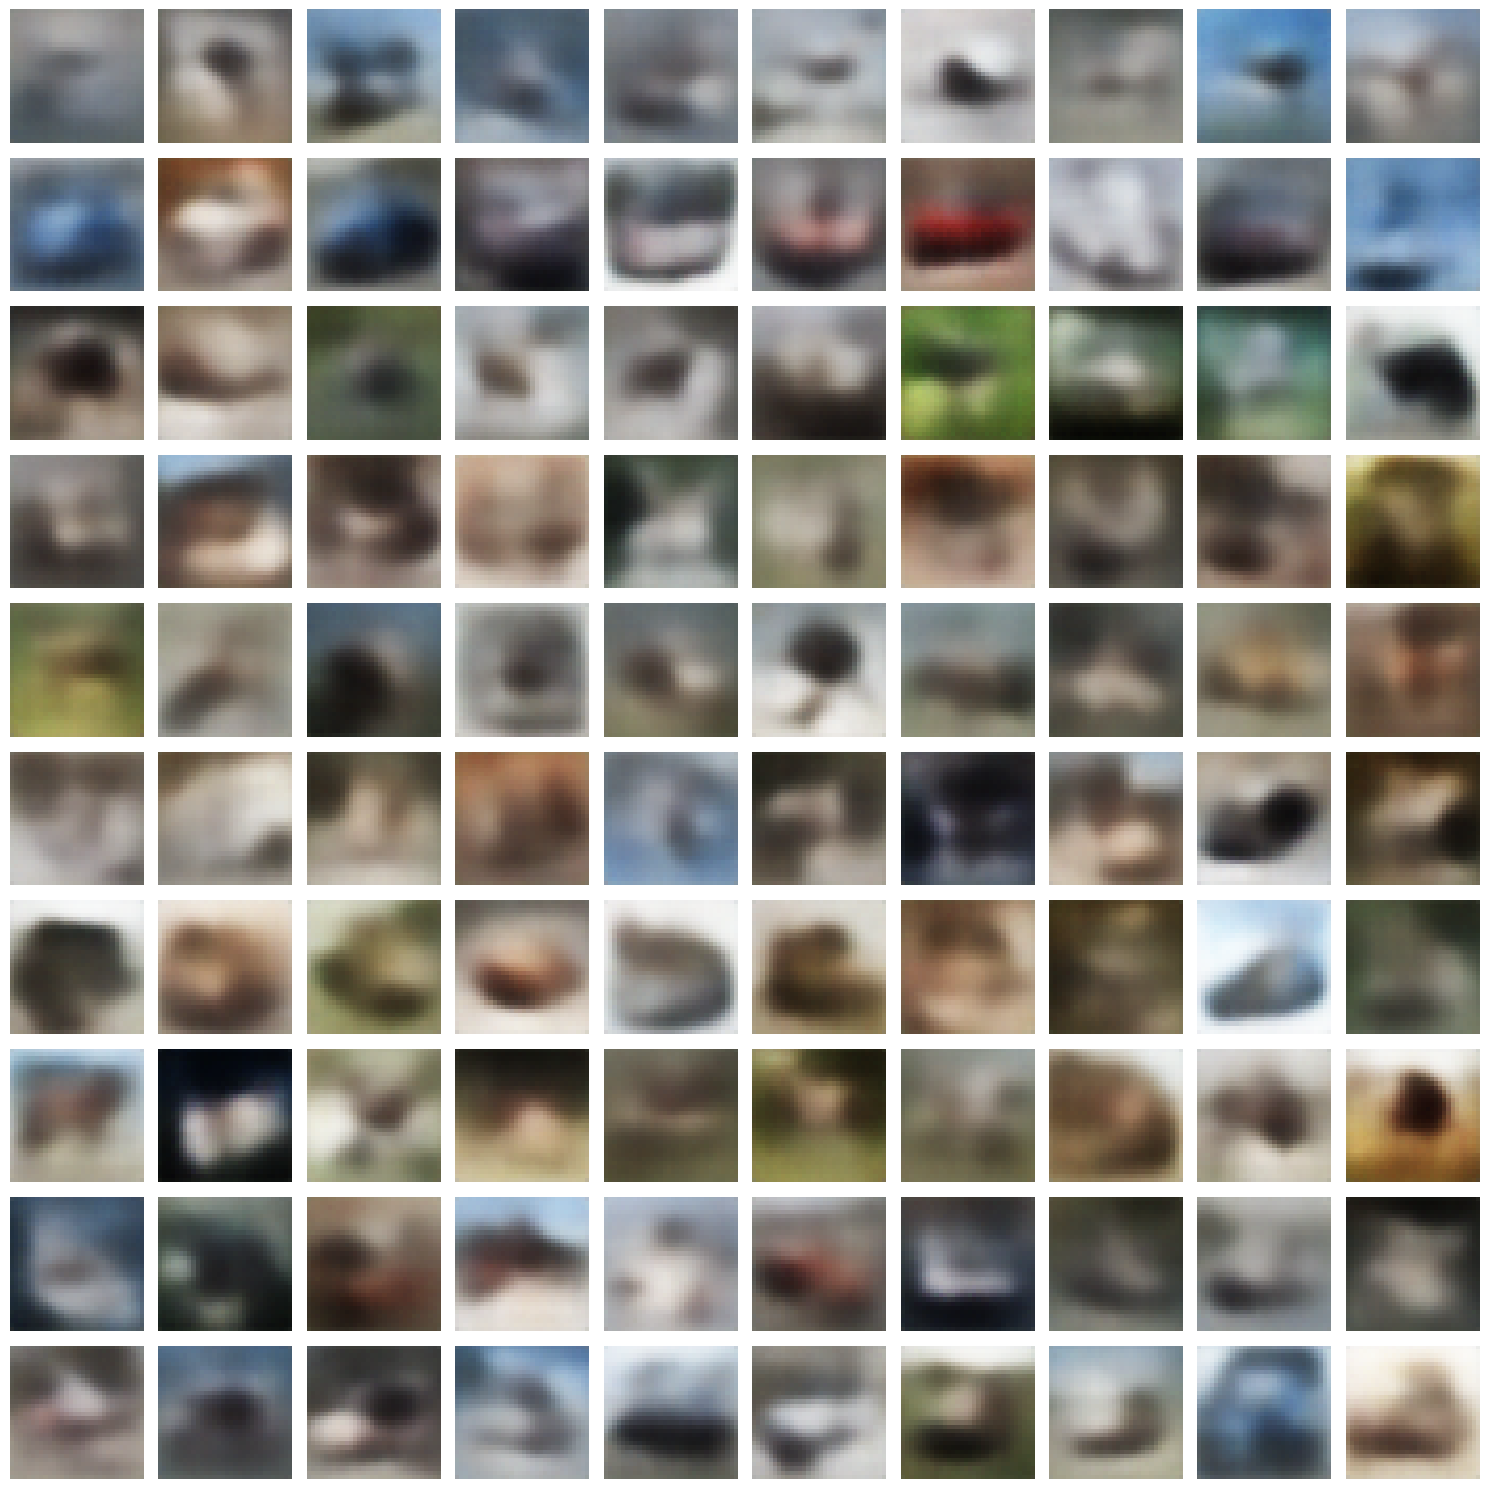

Samples saved to ../result/conditional_vae/cvae_samples_epoch_20.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_20.png


Epoch 21/100: 100%|██████████| 196/196 [00:19<00:00,  9.92it/s, Loss=74.091675, Recon=54.343127, KL=19.748550, KLD Weight=1.0000]

====> Epoch: 21 Average loss: 74.356726 Average Reconstruction Loss: 53.420647 Average KL Loss: 20.936079 KLD Weight: 1.0000



Epoch 22/100: 100%|██████████| 196/196 [00:12<00:00, 15.10it/s, Loss=78.488306, Recon=57.214319, KL=21.273984, KLD Weight=1.0000]

====> Epoch: 22 Average loss: 74.271198 Average Reconstruction Loss: 53.361087 Average KL Loss: 20.910112 KLD Weight: 1.0000


...

====> Epoch: 28 Average loss: 73.899976 Average Reconstruction Loss: 53.005095 Average KL Loss: 20.894882 KLD Weight: 1.0000



Epoch 29/100: 100%|██████████| 196/196 [00:19<00:00, 10.21it/s, Loss=68.749670, Recon=47.699561, KL=21.050107, KLD Weight=1.0000]

====> Epoch: 29 Average loss: 73.719837 Average Reconstruction Loss: 52.798672 Average KL Loss: 20.921165 KLD Weight: 1.0000



Epoch 30/100: 100%|██████████| 196/196 [00:14<00:00, 13.49it/s, Loss=73.846295, Recon=52.610205, KL=21.236090, KLD Weight=1.0000]


====> Epoch: 30 Average loss: 73.651235 Average Reconstruction Loss: 52.719261 Average KL Loss: 20.931973 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_30.pth


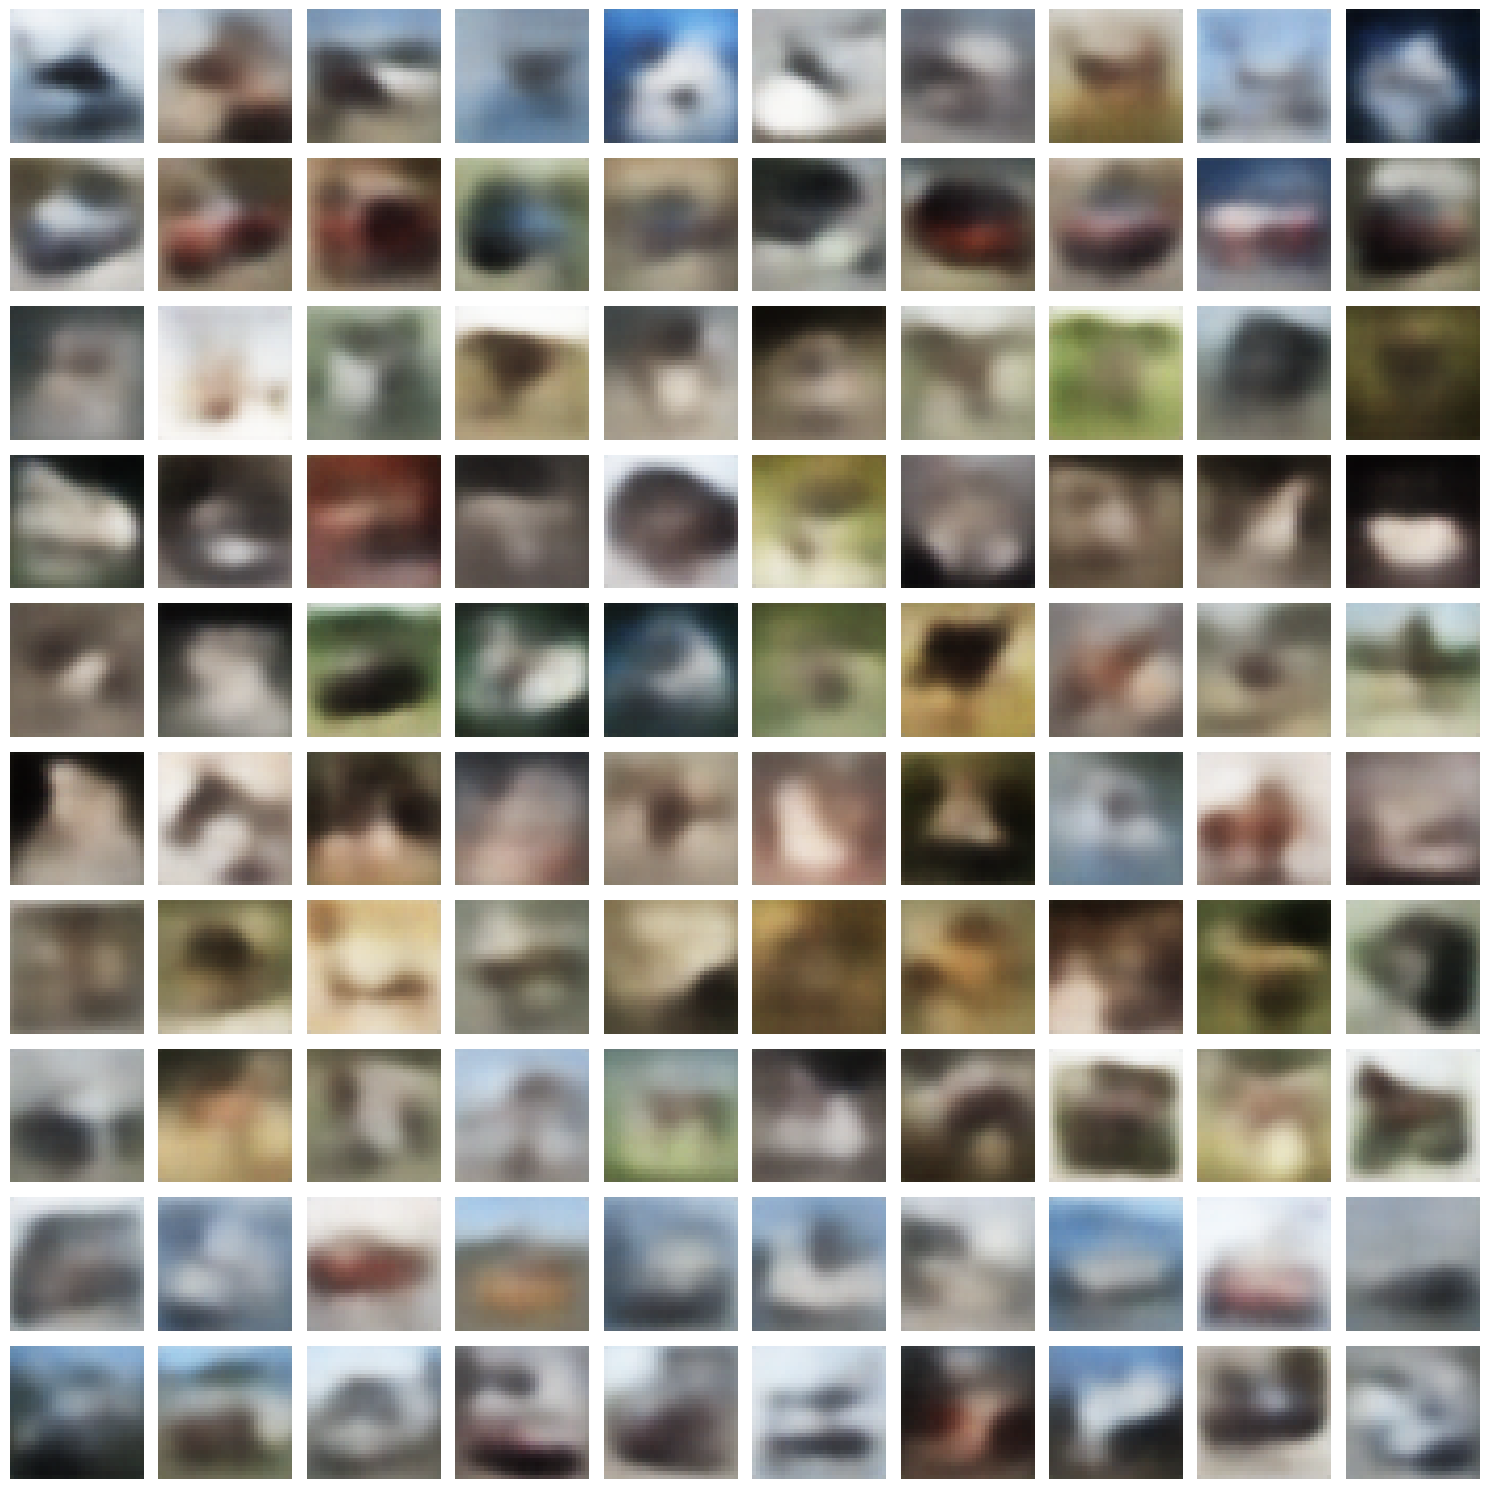

Samples saved to ../result/conditional_vae/cvae_samples_epoch_30.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_30.png


Epoch 31/100: 100%|██████████| 196/196 [00:17<00:00, 11.44it/s, Loss=70.460522, Recon=49.010986, KL=21.449536, KLD Weight=1.0000]

====> Epoch: 31 Average loss: 73.633489 Average Reconstruction Loss: 52.674713 Average KL Loss: 20.958776 KLD Weight: 1.0000



Epoch 32/100: 100%|██████████| 196/196 [00:17<00:00, 11.45it/s, Loss=75.861243, Recon=56.440625, KL=19.420618, KLD Weight=1.0000]

====> Epoch: 32 Average loss: 73.605768 Average Reconstruction Loss: 52.662503 Average KL Loss: 20.943265 KLD Weight: 1.0000


...

====> Epoch: 38 Average loss: 73.314223 Average Reconstruction Loss: 52.274462 Average KL Loss: 21.039761 KLD Weight: 1.0000



Epoch 39/100: 100%|██████████| 196/196 [00:13<00:00, 14.18it/s, Loss=76.164111, Recon=54.409119, KL=21.754996, KLD Weight=1.0000]

====> Epoch: 39 Average loss: 73.281741 Average Reconstruction Loss: 52.249041 Average KL Loss: 21.032700 KLD Weight: 1.0000



Epoch 40/100: 100%|██████████| 196/196 [00:16<00:00, 11.53it/s, Loss=69.020984, Recon=47.358981, KL=21.662006, KLD Weight=1.0000]


====> Epoch: 40 Average loss: 73.157098 Average Reconstruction Loss: 52.152819 Average KL Loss: 21.004279 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_40.pth


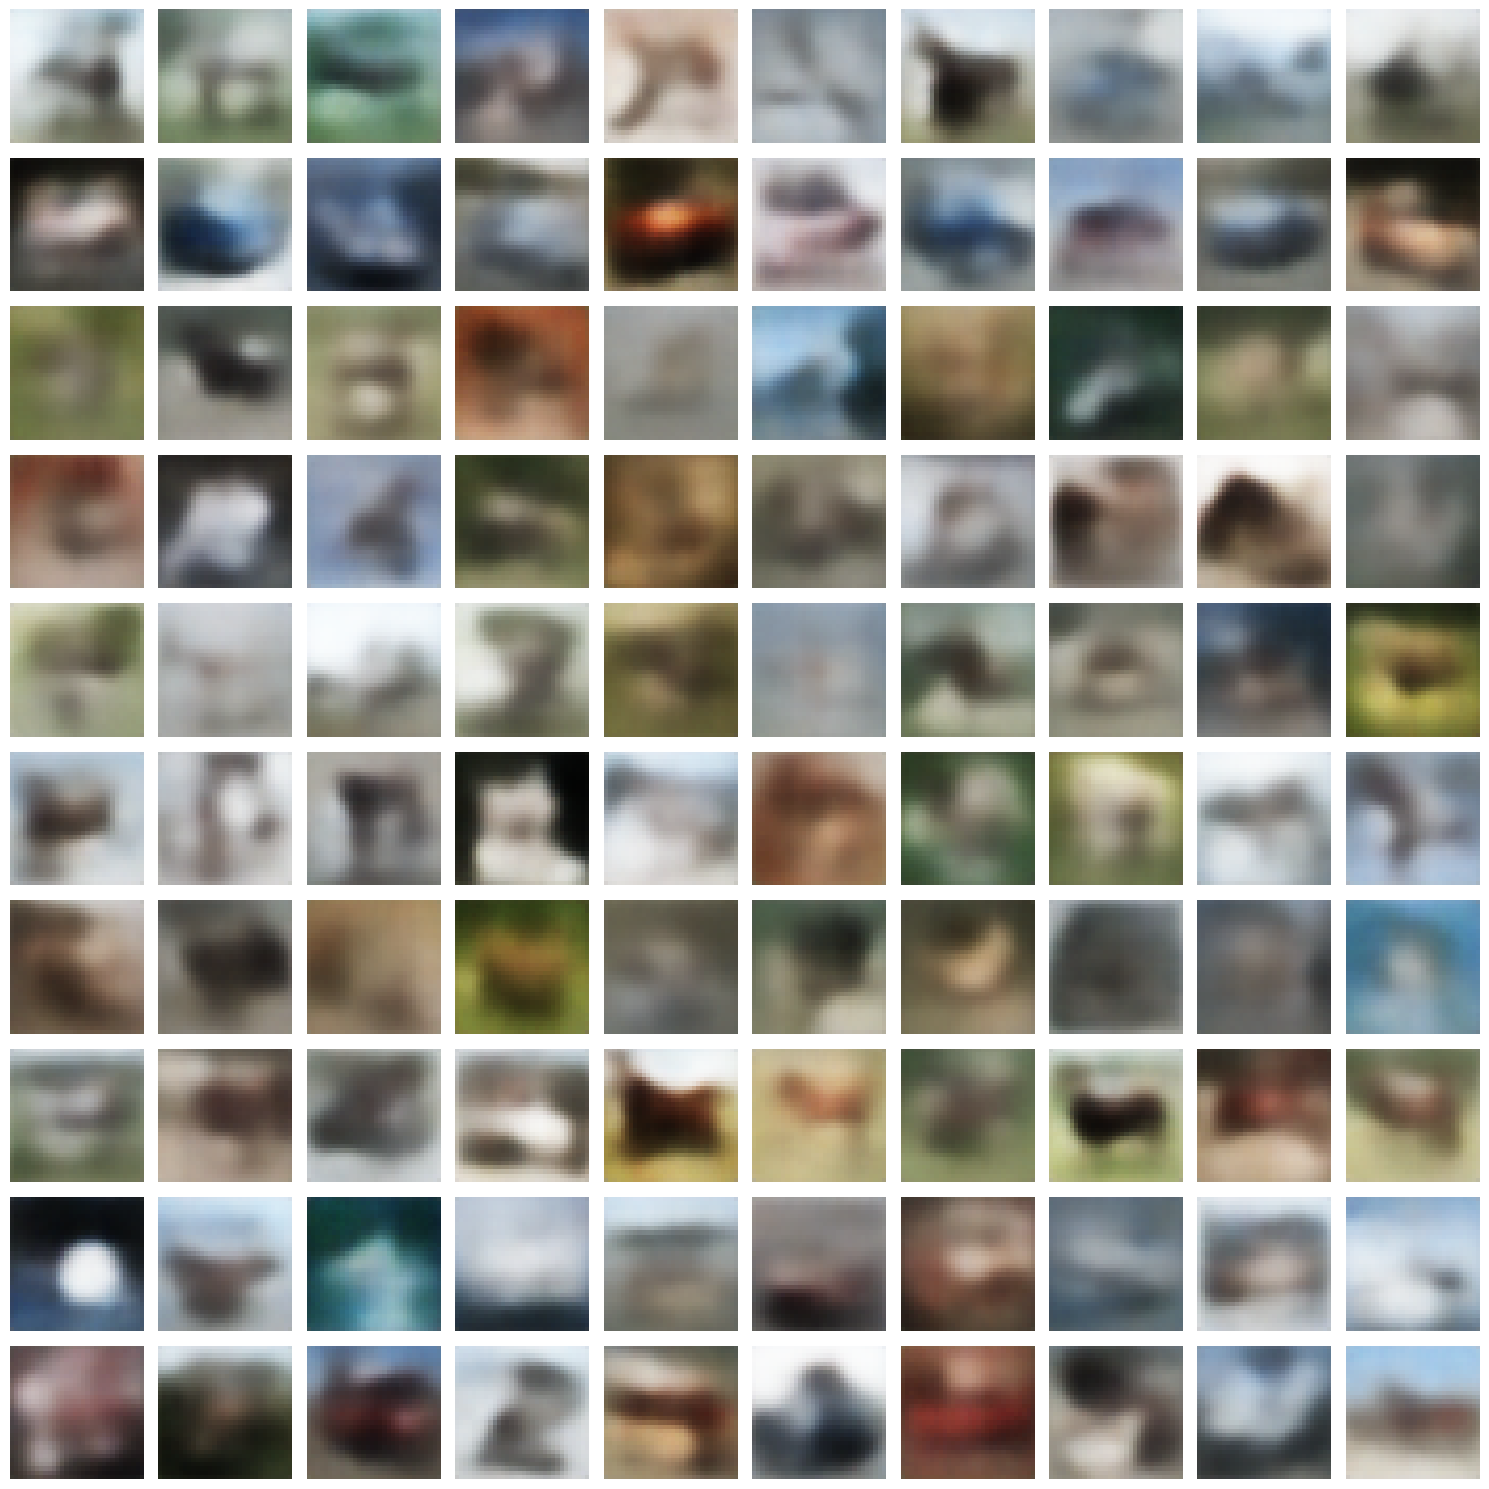

Samples saved to ../result/conditional_vae/cvae_samples_epoch_40.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_40.png


Epoch 41/100: 100%|██████████| 196/196 [00:14<00:00, 13.40it/s, Loss=71.538562, Recon=51.065741, KL=20.472818, KLD Weight=1.0000]

====> Epoch: 41 Average loss: 73.141978 Average Reconstruction Loss: 52.141228 Average KL Loss: 21.000751 KLD Weight: 1.0000



Epoch 42/100: 100%|██████████| 196/196 [00:19<00:00,  9.90it/s, Loss=73.339465, Recon=51.685974, KL=21.653493, KLD Weight=1.0000]

====> Epoch: 42 Average loss: 73.015941 Average Reconstruction Loss: 51.972089 Average KL Loss: 21.043852 KLD Weight: 1.0000


...

====> Epoch: 48 Average loss: 72.954628 Average Reconstruction Loss: 51.903519 Average KL Loss: 21.051109 KLD Weight: 1.0000



Epoch 49/100: 100%|██████████| 196/196 [00:13<00:00, 14.64it/s, Loss=76.125513, Recon=55.380396, KL=20.745117, KLD Weight=1.0000]

====> Epoch: 49 Average loss: 72.865648 Average Reconstruction Loss: 51.848570 Average KL Loss: 21.017078 KLD Weight: 1.0000



Epoch 50/100: 100%|██████████| 196/196 [00:19<00:00, 10.24it/s, Loss=78.643152, Recon=56.609351, KL=22.033801, KLD Weight=1.0000]


====> Epoch: 50 Average loss: 72.761336 Average Reconstruction Loss: 51.739026 Average KL Loss: 21.022310 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_50.pth


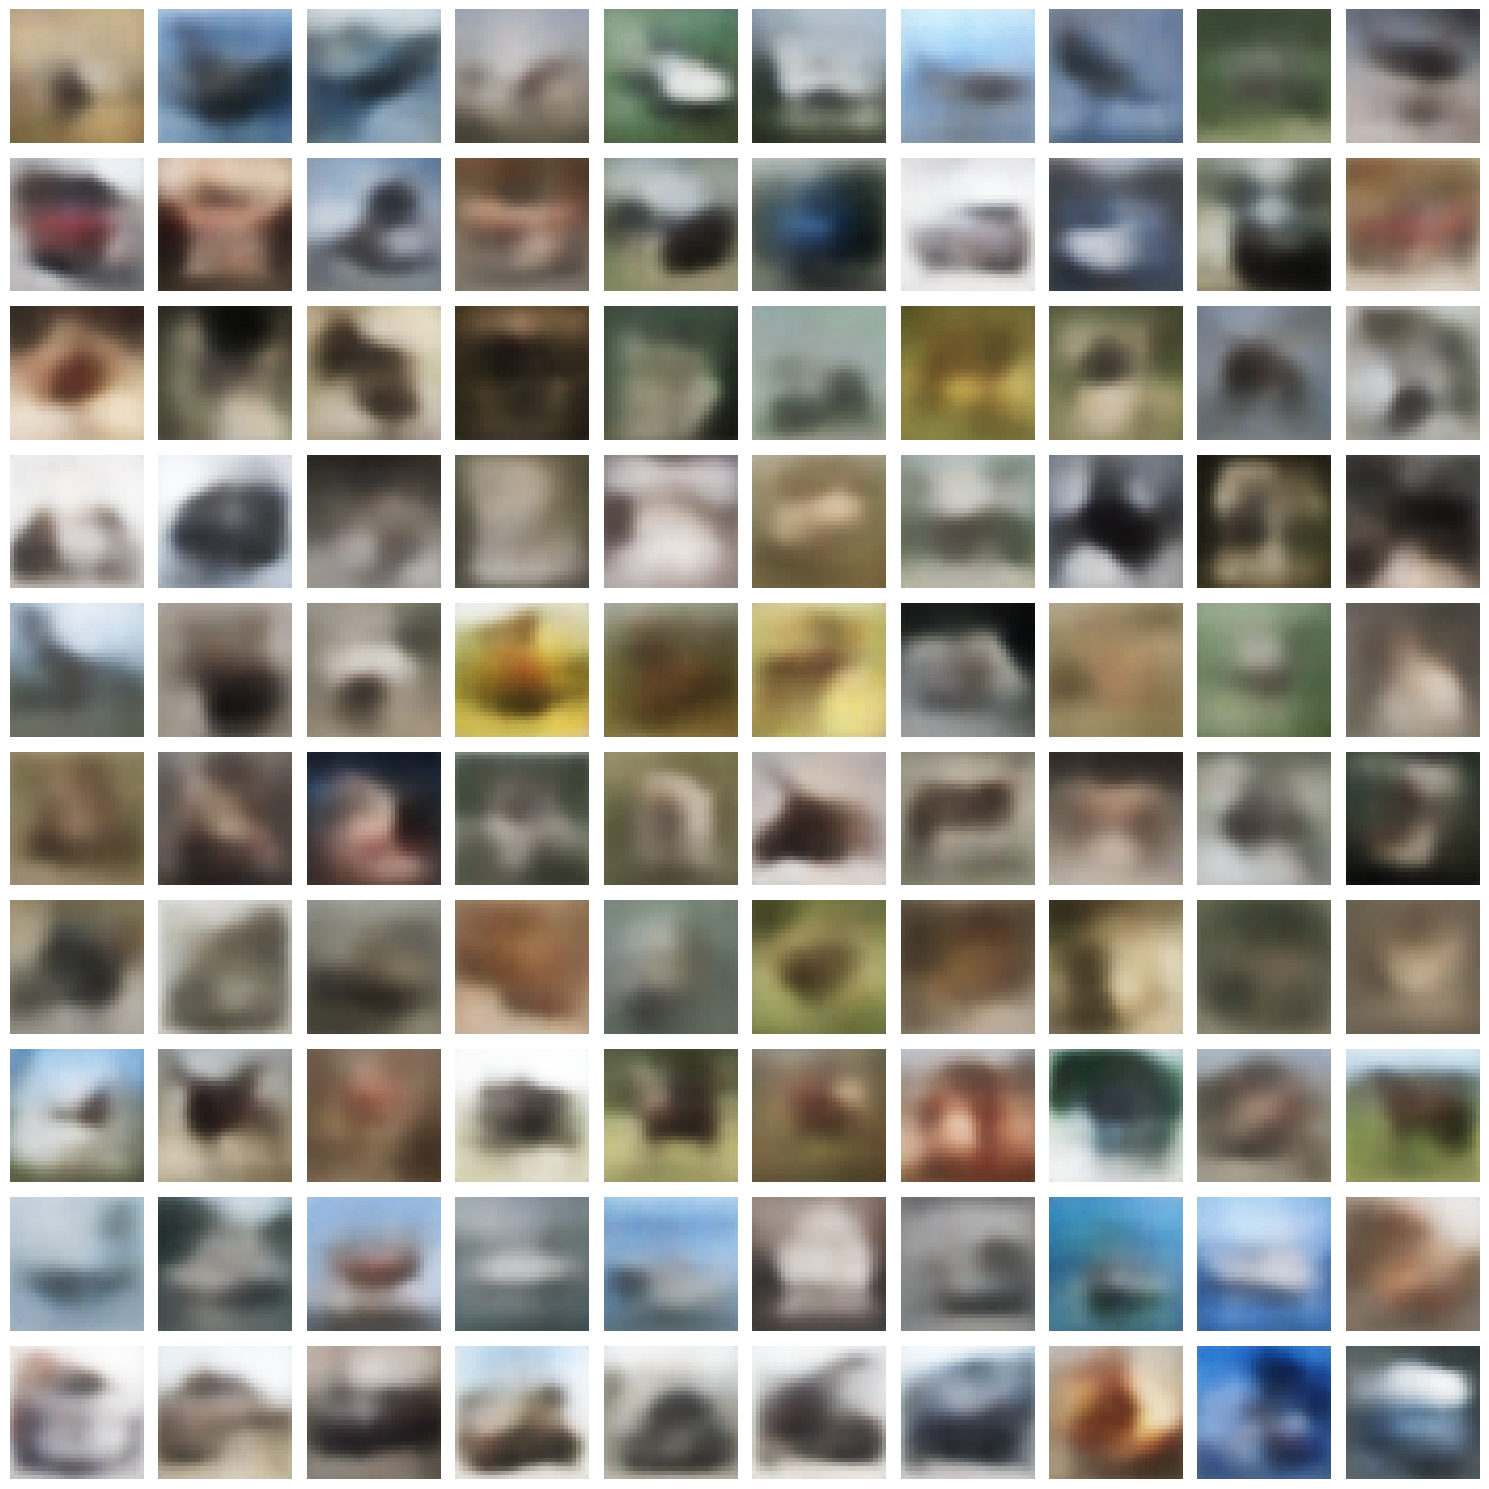

Samples saved to ../result/conditional_vae/cvae_samples_epoch_50.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_50.png


Epoch 51/100: 100%|██████████| 196/196 [00:16<00:00, 11.87it/s, Loss=74.532977, Recon=53.591400, KL=20.941577, KLD Weight=1.0000]

====> Epoch: 51 Average loss: 72.822822 Average Reconstruction Loss: 51.746951 Average KL Loss: 21.075870 KLD Weight: 1.0000



Epoch 52/100: 100%|██████████| 196/196 [00:15<00:00, 12.49it/s, Loss=76.552014, Recon=53.800336, KL=22.751682, KLD Weight=1.0000]

====> Epoch: 52 Average loss: 72.792688 Average Reconstruction Loss: 51.715333 Average KL Loss: 21.077355 KLD Weight: 1.0000


...

====> Epoch: 58 Average loss: 72.463355 Average Reconstruction Loss: 51.386014 Average KL Loss: 21.077342 KLD Weight: 1.0000



Epoch 59/100: 100%|██████████| 196/196 [00:18<00:00, 10.78it/s, Loss=76.032965, Recon=54.524194, KL=21.508769, KLD Weight=1.0000]

====> Epoch: 59 Average loss: 72.453721 Average Reconstruction Loss: 51.395424 Average KL Loss: 21.058297 KLD Weight: 1.0000



Epoch 60/100: 100%|██████████| 196/196 [00:13<00:00, 14.13it/s, Loss=71.408093, Recon=50.178186, KL=21.229909, KLD Weight=1.0000]


====> Epoch: 60 Average loss: 72.431118 Average Reconstruction Loss: 51.350780 Average KL Loss: 21.080338 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_60.pth


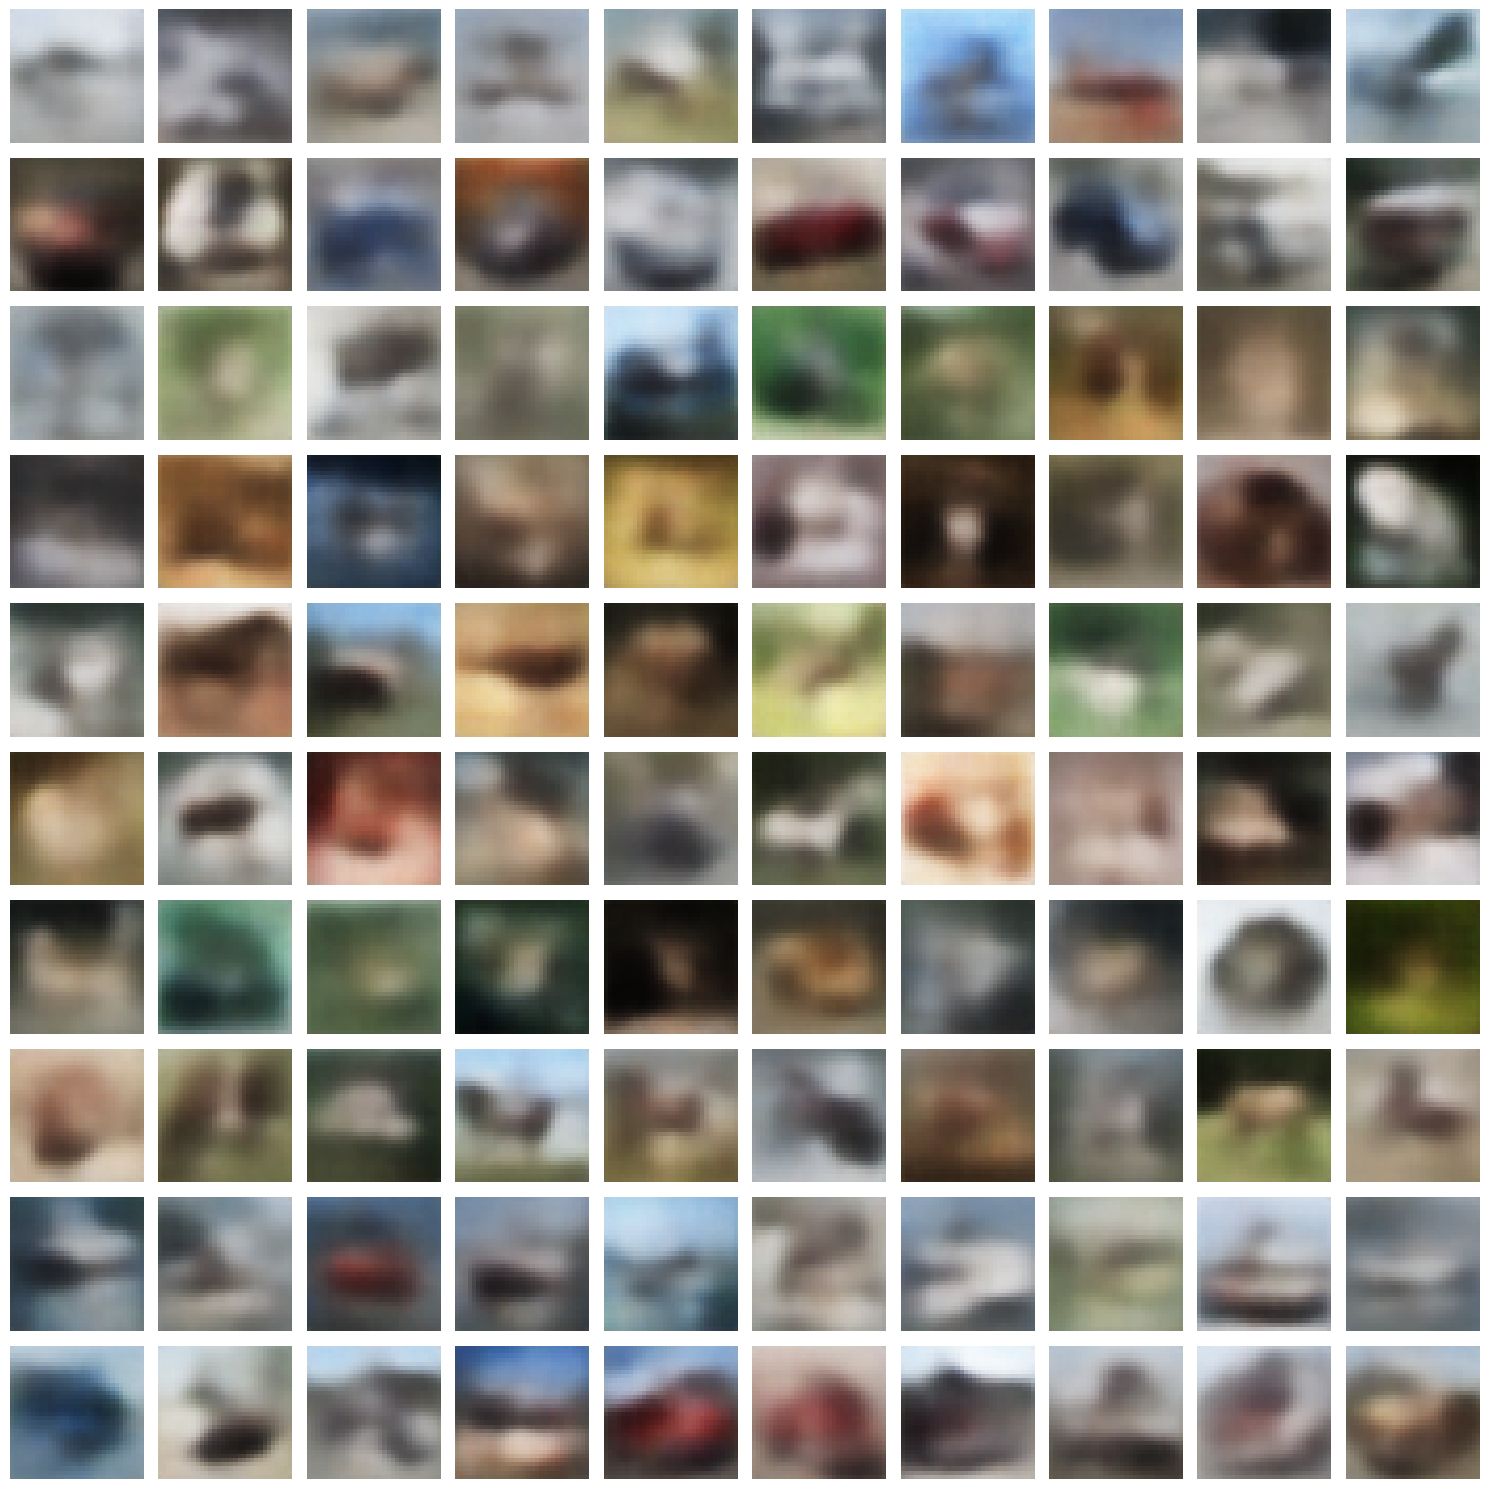

Samples saved to ../result/conditional_vae/cvae_samples_epoch_60.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_60.png


Epoch 61/100: 100%|██████████| 196/196 [00:14<00:00, 13.69it/s, Loss=74.433203, Recon=53.715778, KL=20.717426, KLD Weight=1.0000]

====> Epoch: 61 Average loss: 72.423768 Average Reconstruction Loss: 51.348425 Average KL Loss: 21.075343 KLD Weight: 1.0000



Epoch 62/100: 100%|██████████| 196/196 [00:18<00:00, 10.73it/s, Loss=72.753632, Recon=50.557959, KL=22.195673, KLD Weight=1.0000]

====> Epoch: 62 Average loss: 72.387158 Average Reconstruction Loss: 51.309158 Average KL Loss: 21.078000 KLD Weight: 1.0000


...

====> Epoch: 68 Average loss: 72.134681 Average Reconstruction Loss: 51.034818 Average KL Loss: 21.099863 KLD Weight: 1.0000



Epoch 69/100: 100%|██████████| 196/196 [00:14<00:00, 13.48it/s, Loss=70.677606, Recon=50.231775, KL=20.445831, KLD Weight=1.0000]

====> Epoch: 69 Average loss: 72.221655 Average Reconstruction Loss: 51.103664 Average KL Loss: 21.117991 KLD Weight: 1.0000



Epoch 70/100: 100%|██████████| 196/196 [00:14<00:00, 13.62it/s, Loss=68.770544, Recon=48.311649, KL=20.458896, KLD Weight=1.0000]


====> Epoch: 70 Average loss: 72.188777 Average Reconstruction Loss: 51.082912 Average KL Loss: 21.105864 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_70.pth


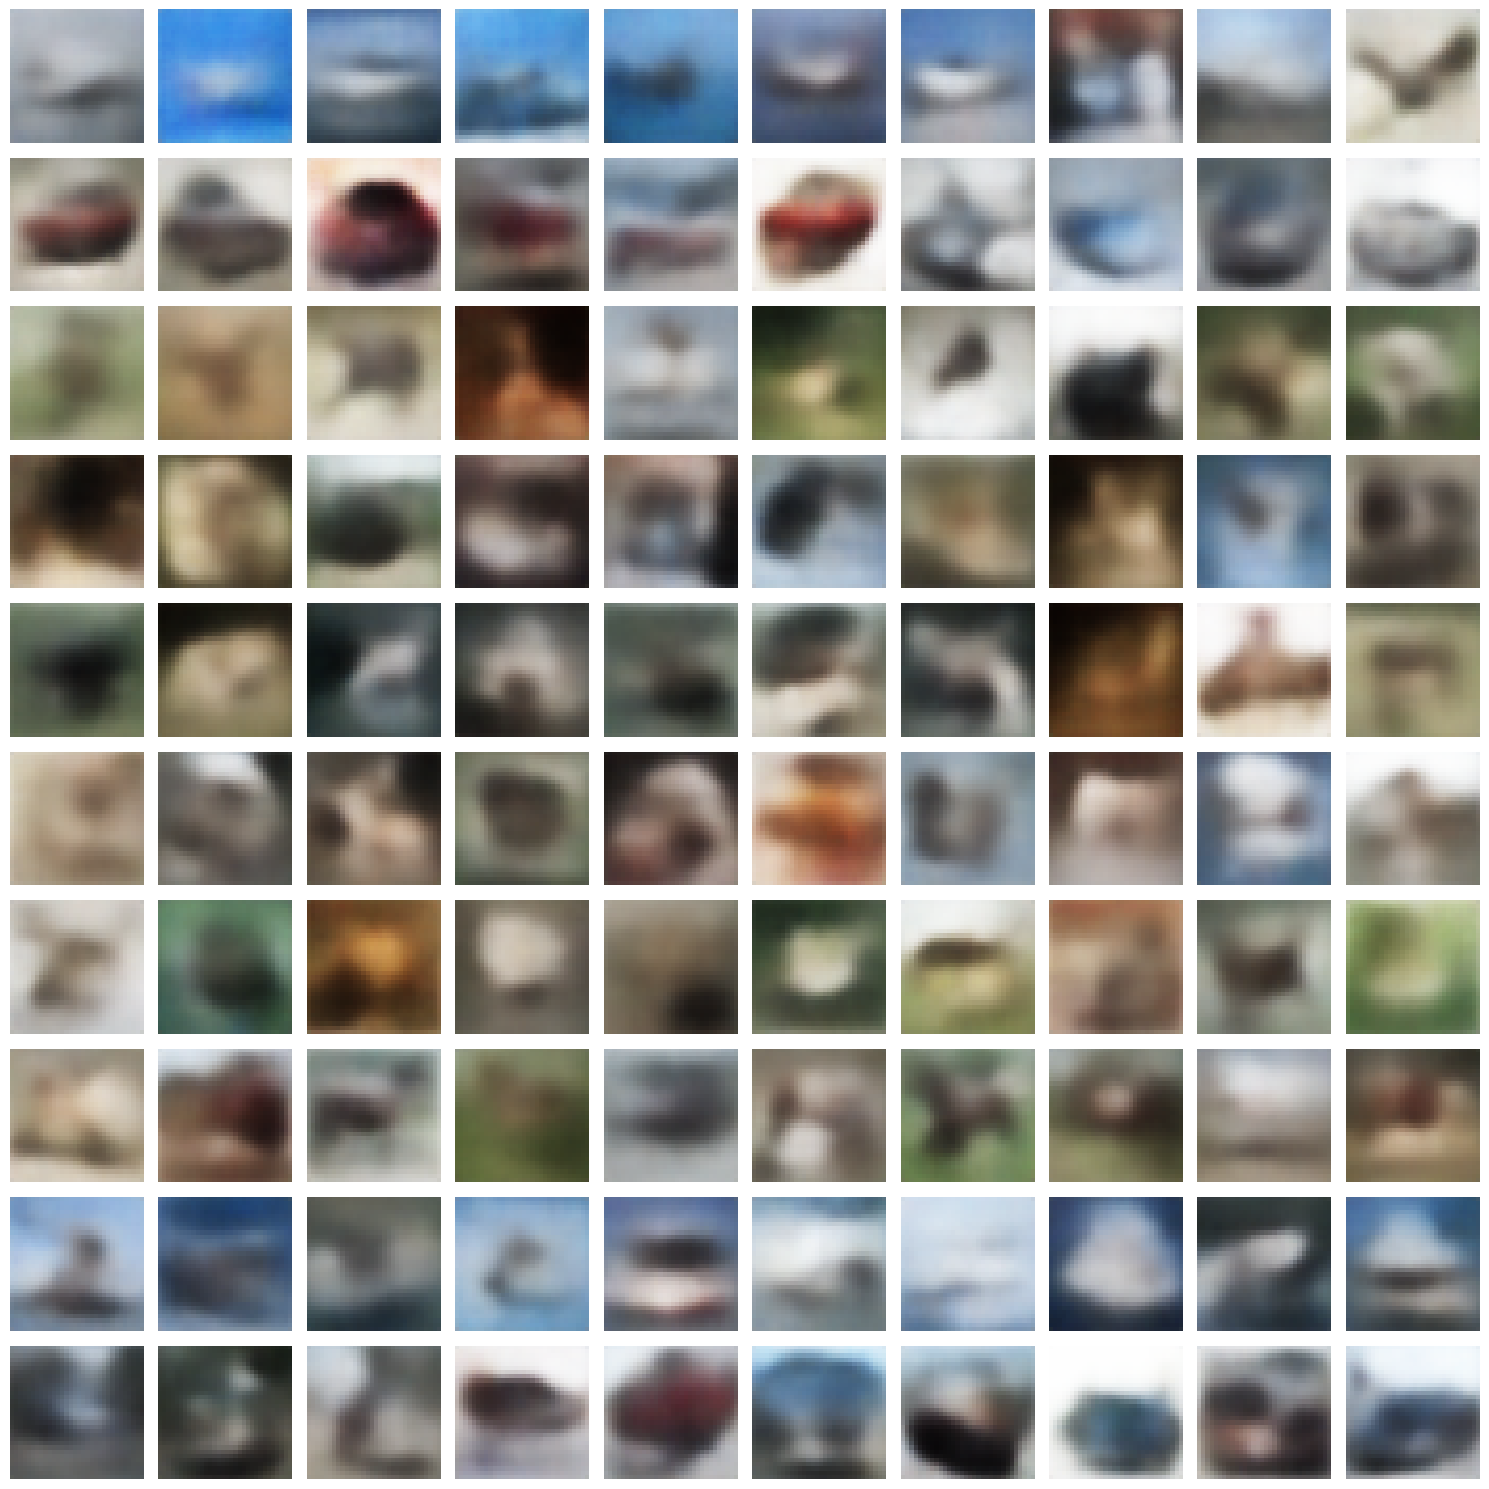

Samples saved to ../result/conditional_vae/cvae_samples_epoch_70.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_70.png


Epoch 71/100: 100%|██████████| 196/196 [00:18<00:00, 10.62it/s, Loss=74.865472, Recon=53.282166, KL=21.583307, KLD Weight=1.0000]

====> Epoch: 71 Average loss: 72.130431 Average Reconstruction Loss: 51.007423 Average KL Loss: 21.123008 KLD Weight: 1.0000



Epoch 72/100: 100%|██████████| 196/196 [00:16<00:00, 12.00it/s, Loss=76.002917, Recon=55.709937, KL=20.292979, KLD Weight=1.0000]

====> Epoch: 72 Average loss: 72.111383 Average Reconstruction Loss: 50.992238 Average KL Loss: 21.119145 KLD Weight: 1.0000


...

====> Epoch: 78 Average loss: 71.960905 Average Reconstruction Loss: 50.824987 Average KL Loss: 21.135918 KLD Weight: 1.0000



Epoch 79/100: 100%|██████████| 196/196 [00:17<00:00, 11.37it/s, Loss=71.144580, Recon=50.610925, KL=20.533656, KLD Weight=1.0000]

====> Epoch: 79 Average loss: 71.999844 Average Reconstruction Loss: 50.869520 Average KL Loss: 21.130324 KLD Weight: 1.0000



Epoch 80/100: 100%|██████████| 196/196 [00:15<00:00, 12.65it/s, Loss=77.427307, Recon=55.689062, KL=21.738246, KLD Weight=1.0000]


====> Epoch: 80 Average loss: 71.943378 Average Reconstruction Loss: 50.808052 Average KL Loss: 21.135325 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_80.pth


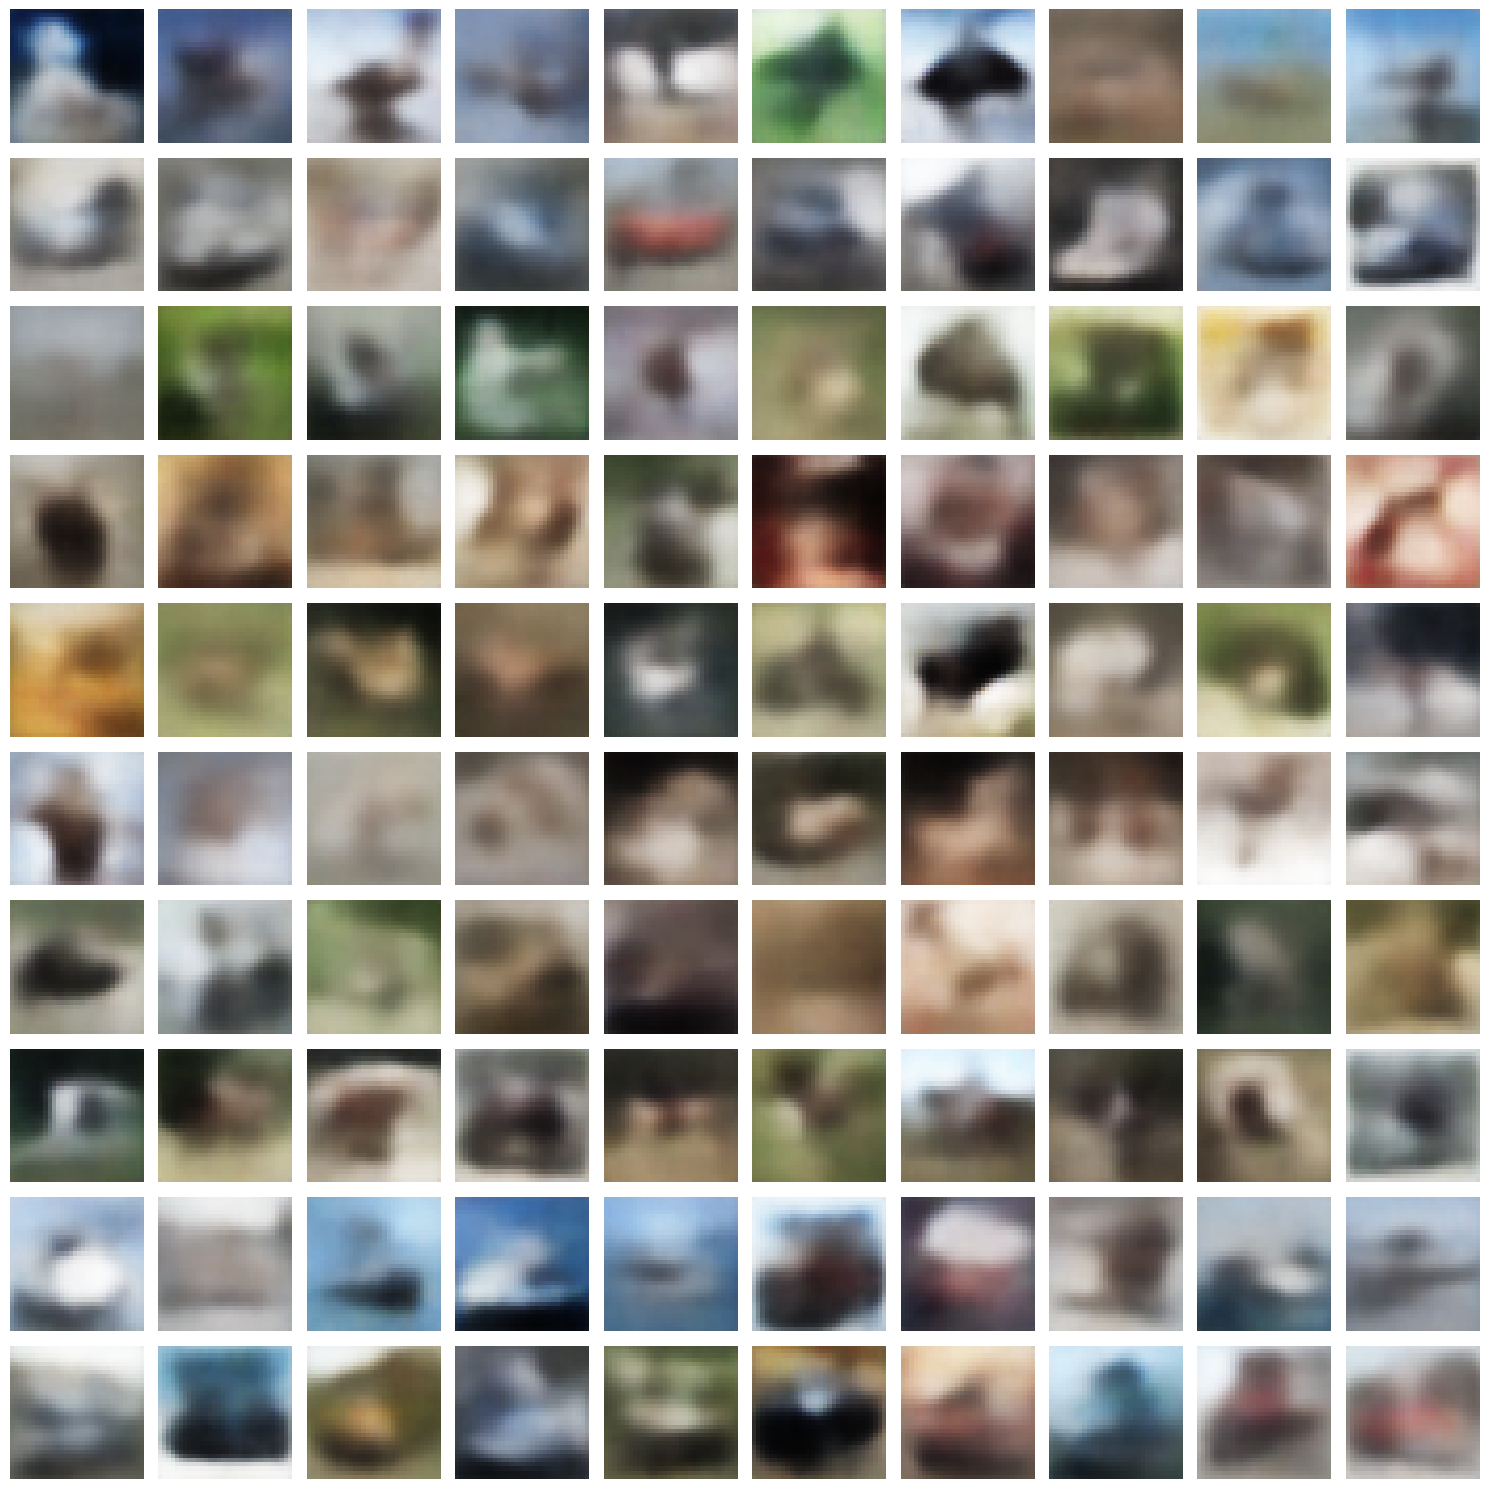

Samples saved to ../result/conditional_vae/cvae_samples_epoch_80.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_80.png


Epoch 81/100: 100%|██████████| 196/196 [00:18<00:00, 10.70it/s, Loss=75.853540, Recon=54.569250, KL=21.284286, KLD Weight=1.0000]

====> Epoch: 81 Average loss: 71.949515 Average Reconstruction Loss: 50.785826 Average KL Loss: 21.163689 KLD Weight: 1.0000



Epoch 82/100: 100%|██████████| 196/196 [00:13<00:00, 15.04it/s, Loss=69.822131, Recon=49.899442, KL=19.922687, KLD Weight=1.0000]

====> Epoch: 82 Average loss: 71.937083 Average Reconstruction Loss: 50.810164 Average KL Loss: 21.126918 KLD Weight: 1.0000


...

====> Epoch: 88 Average loss: 71.737152 Average Reconstruction Loss: 50.582527 Average KL Loss: 21.154624 KLD Weight: 1.0000



Epoch 89/100: 100%|██████████| 196/196 [00:18<00:00, 10.62it/s, Loss=74.863049, Recon=53.890961, KL=20.972086, KLD Weight=1.0000]

====> Epoch: 89 Average loss: 71.723285 Average Reconstruction Loss: 50.564339 Average KL Loss: 21.158946 KLD Weight: 1.0000



Epoch 90/100: 100%|██████████| 196/196 [00:14<00:00, 13.42it/s, Loss=74.601202, Recon=52.361060, KL=22.240141, KLD Weight=1.0000]


====> Epoch: 90 Average loss: 71.710780 Average Reconstruction Loss: 50.520906 Average KL Loss: 21.189874 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_90.pth


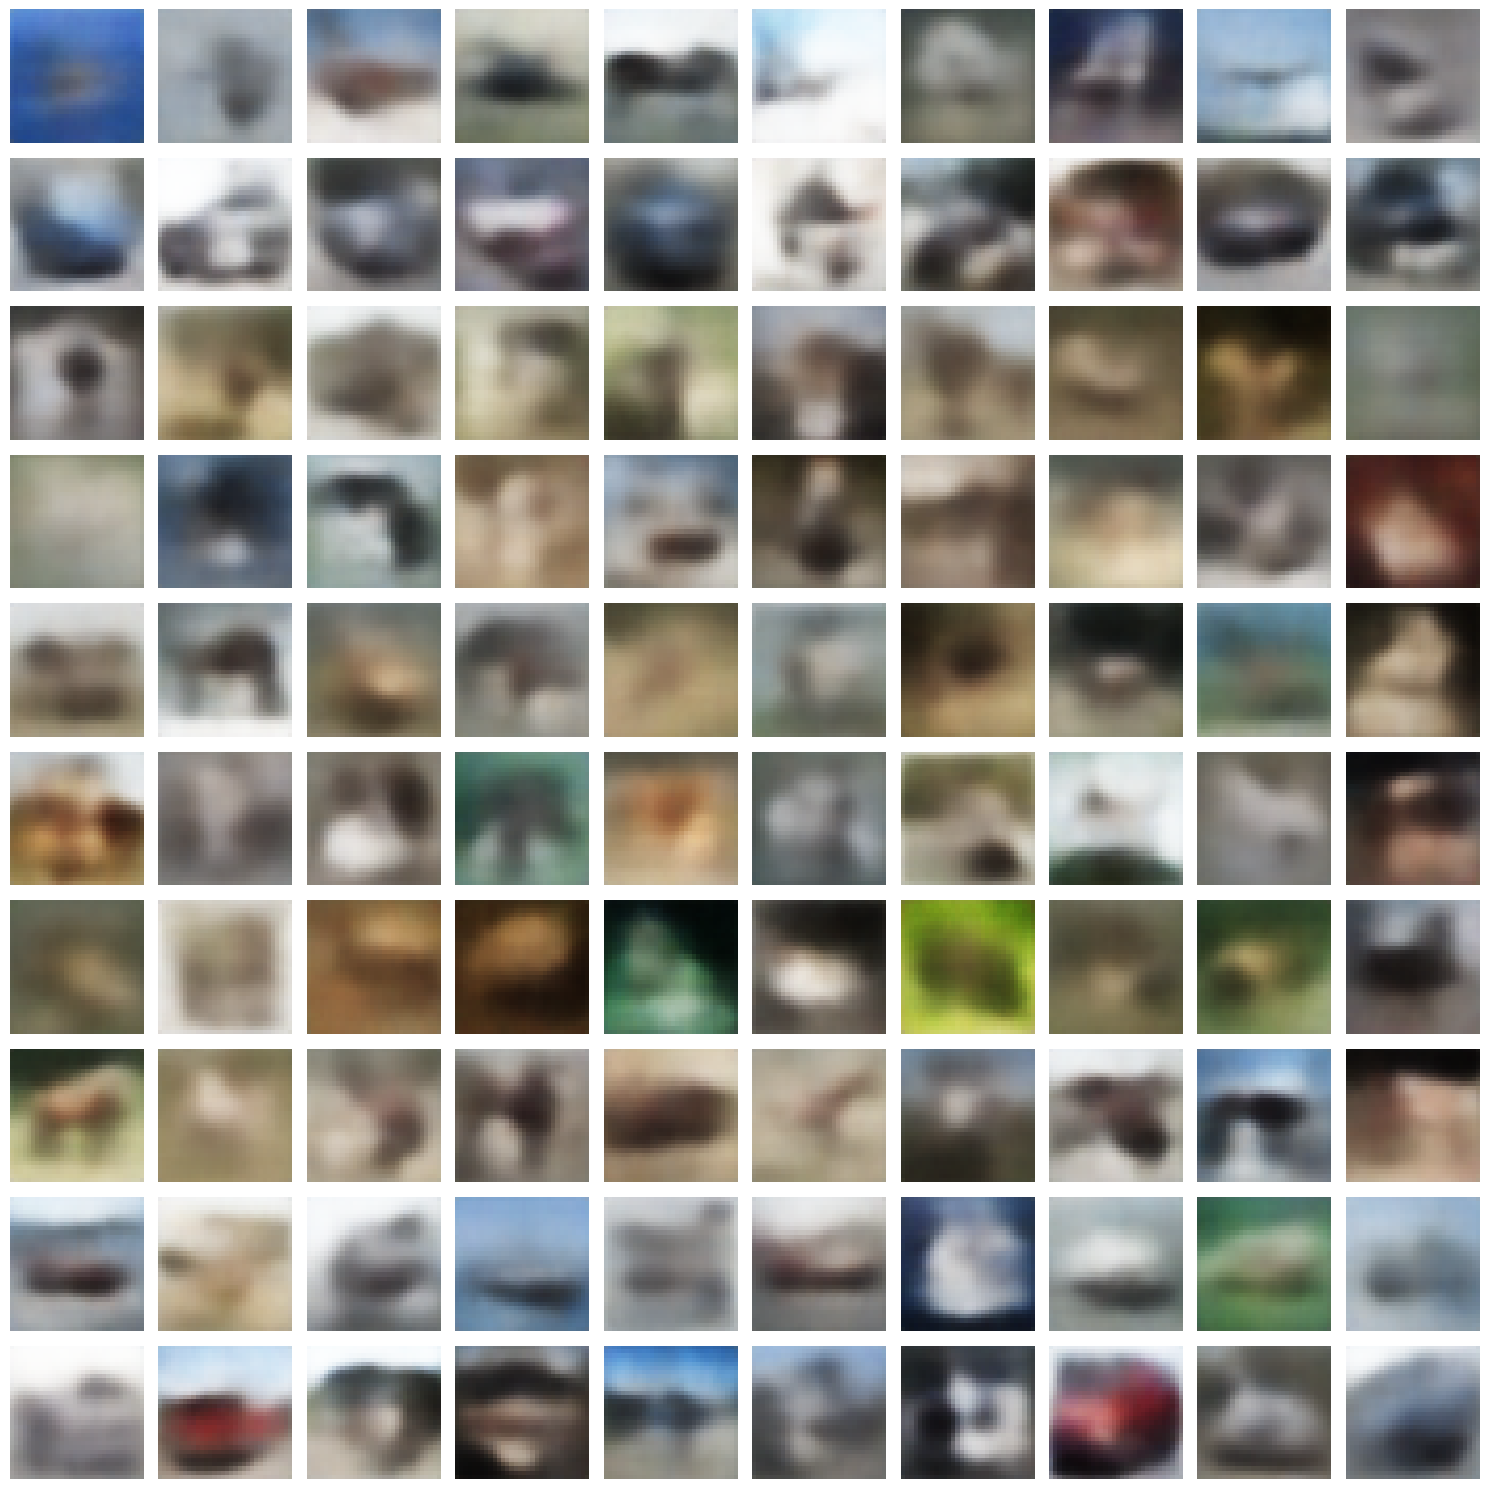

Samples saved to ../result/conditional_vae/cvae_samples_epoch_90.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_90.png


Epoch 91/100: 100%|██████████| 196/196 [00:14<00:00, 13.42it/s, Loss=71.666199, Recon=51.149585, KL=20.516614, KLD Weight=1.0000]

====> Epoch: 91 Average loss: 71.630748 Average Reconstruction Loss: 50.487651 Average KL Loss: 21.143097 KLD Weight: 1.0000



Epoch 92/100: 100%|██████████| 196/196 [00:15<00:00, 12.41it/s, Loss=71.890985, Recon=51.918518, KL=19.972469, KLD Weight=1.0000]

====> Epoch: 92 Average loss: 71.659678 Average Reconstruction Loss: 50.479362 Average KL Loss: 21.180316 KLD Weight: 1.0000


...

====> Epoch: 98 Average loss: 71.528821 Average Reconstruction Loss: 50.356006 Average KL Loss: 21.172816 KLD Weight: 1.0000



Epoch 99/100: 100%|██████████| 196/196 [00:13<00:00, 14.95it/s, Loss=71.803680, Recon=50.761026, KL=21.042656, KLD Weight=1.0000]

====> Epoch: 99 Average loss: 71.482315 Average Reconstruction Loss: 50.292999 Average KL Loss: 21.189316 KLD Weight: 1.0000



Epoch 100/100: 100%|██████████| 196/196 [00:18<00:00, 10.67it/s, Loss=70.839911, Recon=50.444373, KL=20.395538, KLD Weight=1.0000]


====> Epoch: 100 Average loss: 71.502215 Average Reconstruction Loss: 50.287332 Average KL Loss: 21.214883 KLD Weight: 1.0000
Model saved to ../model/conditional_vae/cvae_epoch_100.pth


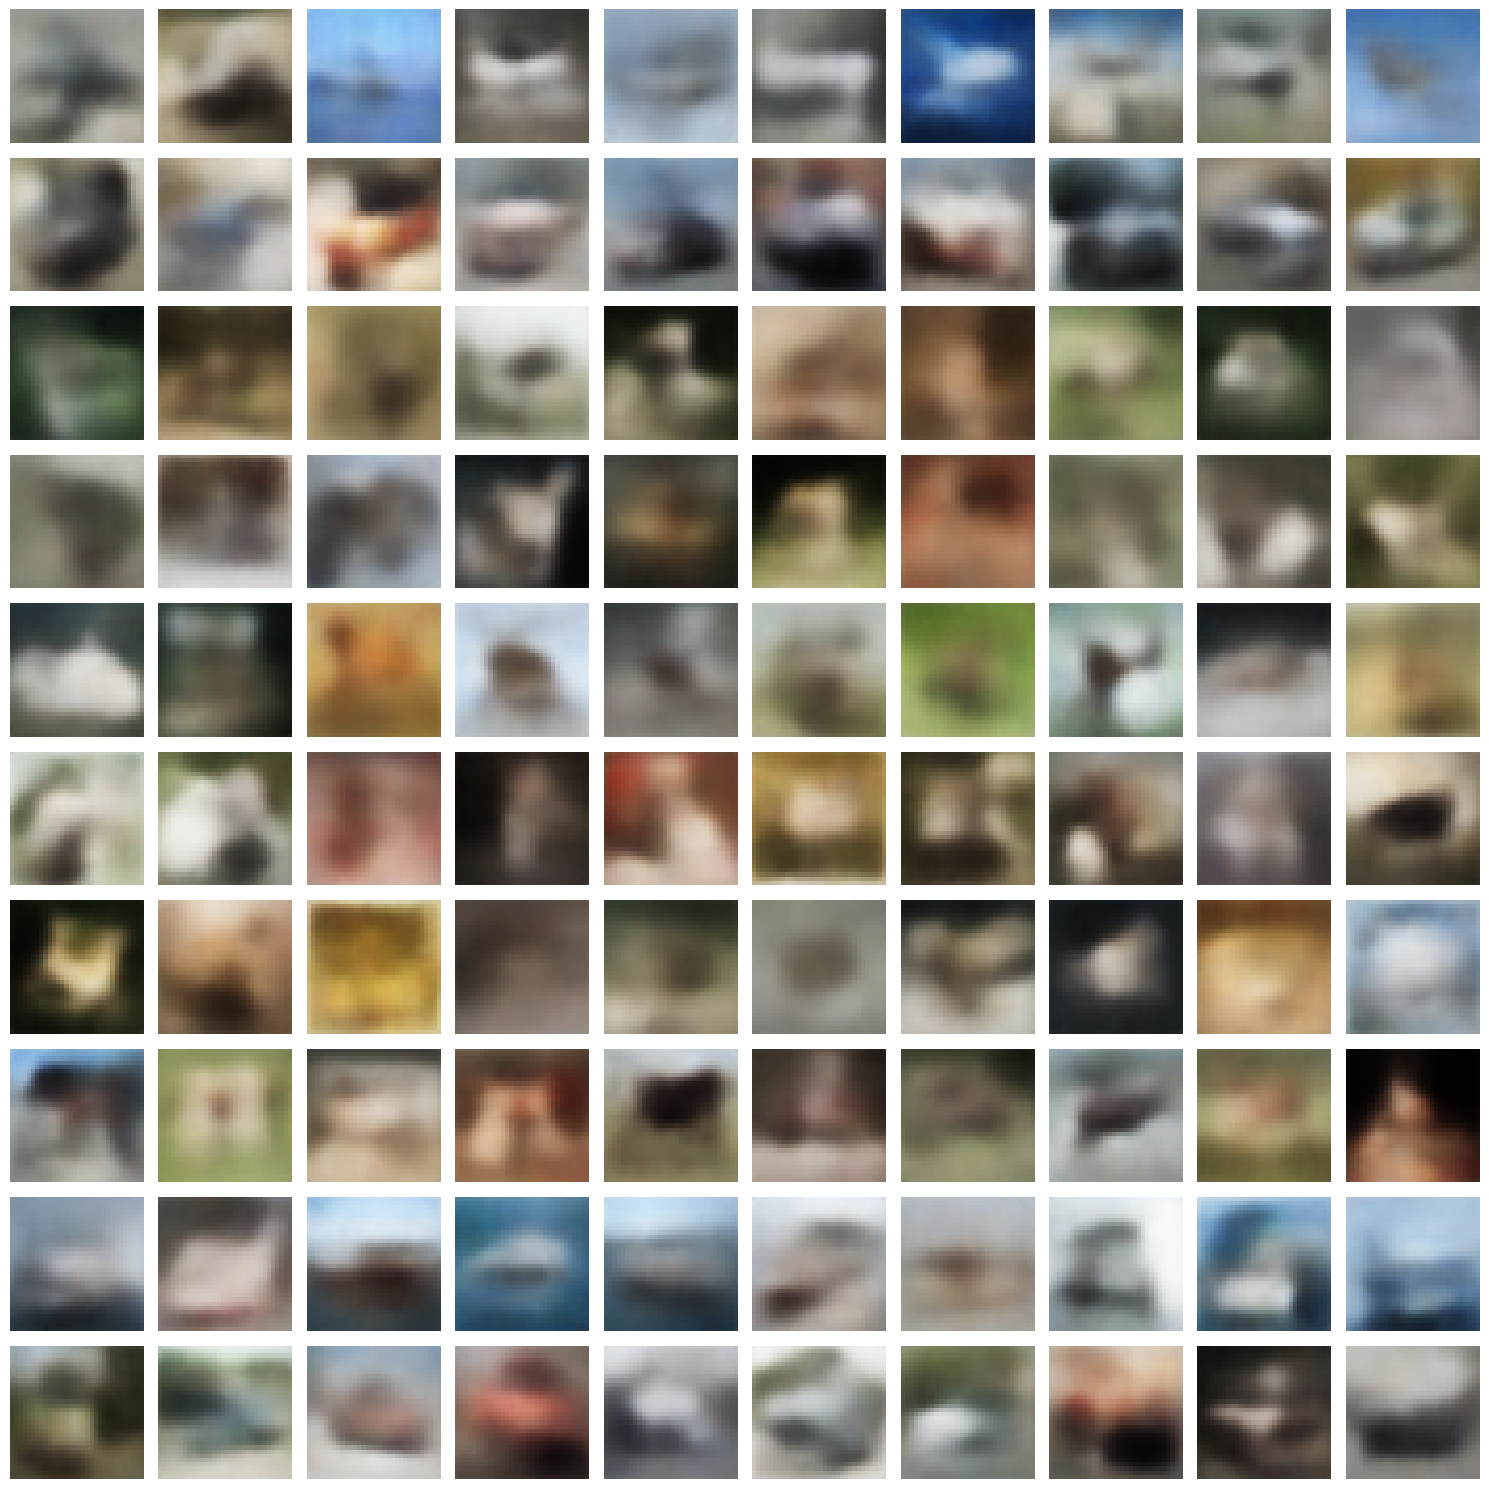

Samples saved to ../result/conditional_vae/cvae_samples_epoch_100.png
Reconstruction comparison saved to ../result/conditional_vae/cvae_reconstruction_epoch_100.png
Final model saved to ../model/conditional_vae/cvae_final.pth


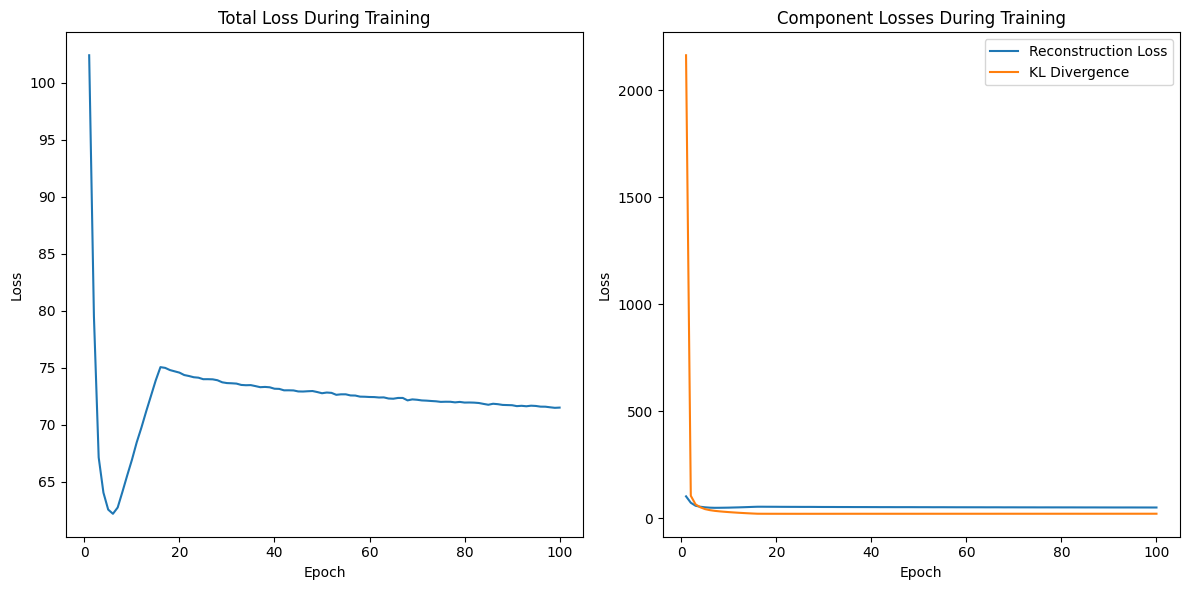

Loss plot saved to ../result/conditional_vae/cvae_loss_plot.png


In [10]:
losses = []
recon_losses = []
kl_losses = []

# Track best model
best_loss = float('inf')
best_epoch = 0

# Train the model
for epoch in range(1, num_epochs + 1):
    # Get KL weight for this epoch (gradual annealing)
    kld_weight = kl_annealing_weight(epoch - 1, start_weight=0.0, end_weight=1.0, annealing_epochs=15)
    
    # Train for one epoch
    epoch_loss, epoch_recon_loss, epoch_kl_loss = train(epoch, kld_weight)
    
    # Record losses
    losses.append(epoch_loss)
    recon_losses.append(epoch_recon_loss)
    kl_losses.append(epoch_kl_loss)
    
    # Save model checkpoint periodically
    if epoch % 10 == 0:
        model_path = f'{MODEL_SAVE_PATH}/cvae_epoch_{epoch}.pth'
        torch.save(model.state_dict(), model_path)
        print(f"Model saved to {model_path}")
        
        # Generate and display conditional samples
        samples, labels = generate_conditional_samples(model)
        save_path = f'{RESULT_SAVE_PATH}/cvae_samples_epoch_{epoch}.png'
        display_samples(samples, labels, save_path=save_path)
        print(f"Samples saved to {save_path}")
        
        # Also show reconstructions of test samples
        with torch.no_grad():
            # Get some test data
            test_data, test_labels = next(iter(train_loader))
            test_data, test_labels = test_data[:10].to(device), test_labels[:10].to(device)
            
            # Reconstruct
            recon, _, _ = model(test_data, test_labels)
            
            # Plot original vs reconstructed
            comparison = torch.cat([test_data[:10], recon[:10]])
            comparison_path = f'{RESULT_SAVE_PATH}/cvae_reconstruction_epoch_{epoch}.png'

            plt.figure(figsize=(10, 4))
            for i in range(20):
                plt.subplot(2, 10, i + 1)
                plt.imshow(comparison[i].cpu().permute(1, 2, 0).numpy())
                plt.axis('off')
                if i < 10:
                    plt.title(f"Original {test_labels[i].item()}")
                else:
                    plt.title(f"Recon {test_labels[i-10].item()}")
            plt.tight_layout()
            plt.savefig(comparison_path)
            plt.close()
            print(f"Reconstruction comparison saved to {comparison_path}")
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_epoch = epoch
        best_model_path = f'{MODEL_SAVE_PATH}/cvae_best.pth'
        torch.save(model.state_dict(), best_model_path)
        print(f"New best model saved at epoch {best_epoch} with loss: {best_loss:.6f}")

# Save the final model
final_model_path = f'{MODEL_SAVE_PATH}/cvae_final.pth'
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to {final_model_path}")

# Plot the training losses
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Total Loss During Training')
plt.plot(range(1, num_epochs + 1), losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.title('Component Losses During Training')
plt.plot(range(1, num_epochs + 1), recon_losses, label='Reconstruction Loss')
plt.plot(range(1, num_epochs + 1), kl_losses, label='KL Divergence')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

loss_plot_path = f'{RESULT_SAVE_PATH}/cvae_loss_plot.png'
plt.tight_layout()
plt.savefig(loss_plot_path)
plt.show()
print(f"Loss plot saved to {loss_plot_path}")

Loading best model from epoch 6


<Figure size 1500x1500 with 0 Axes>

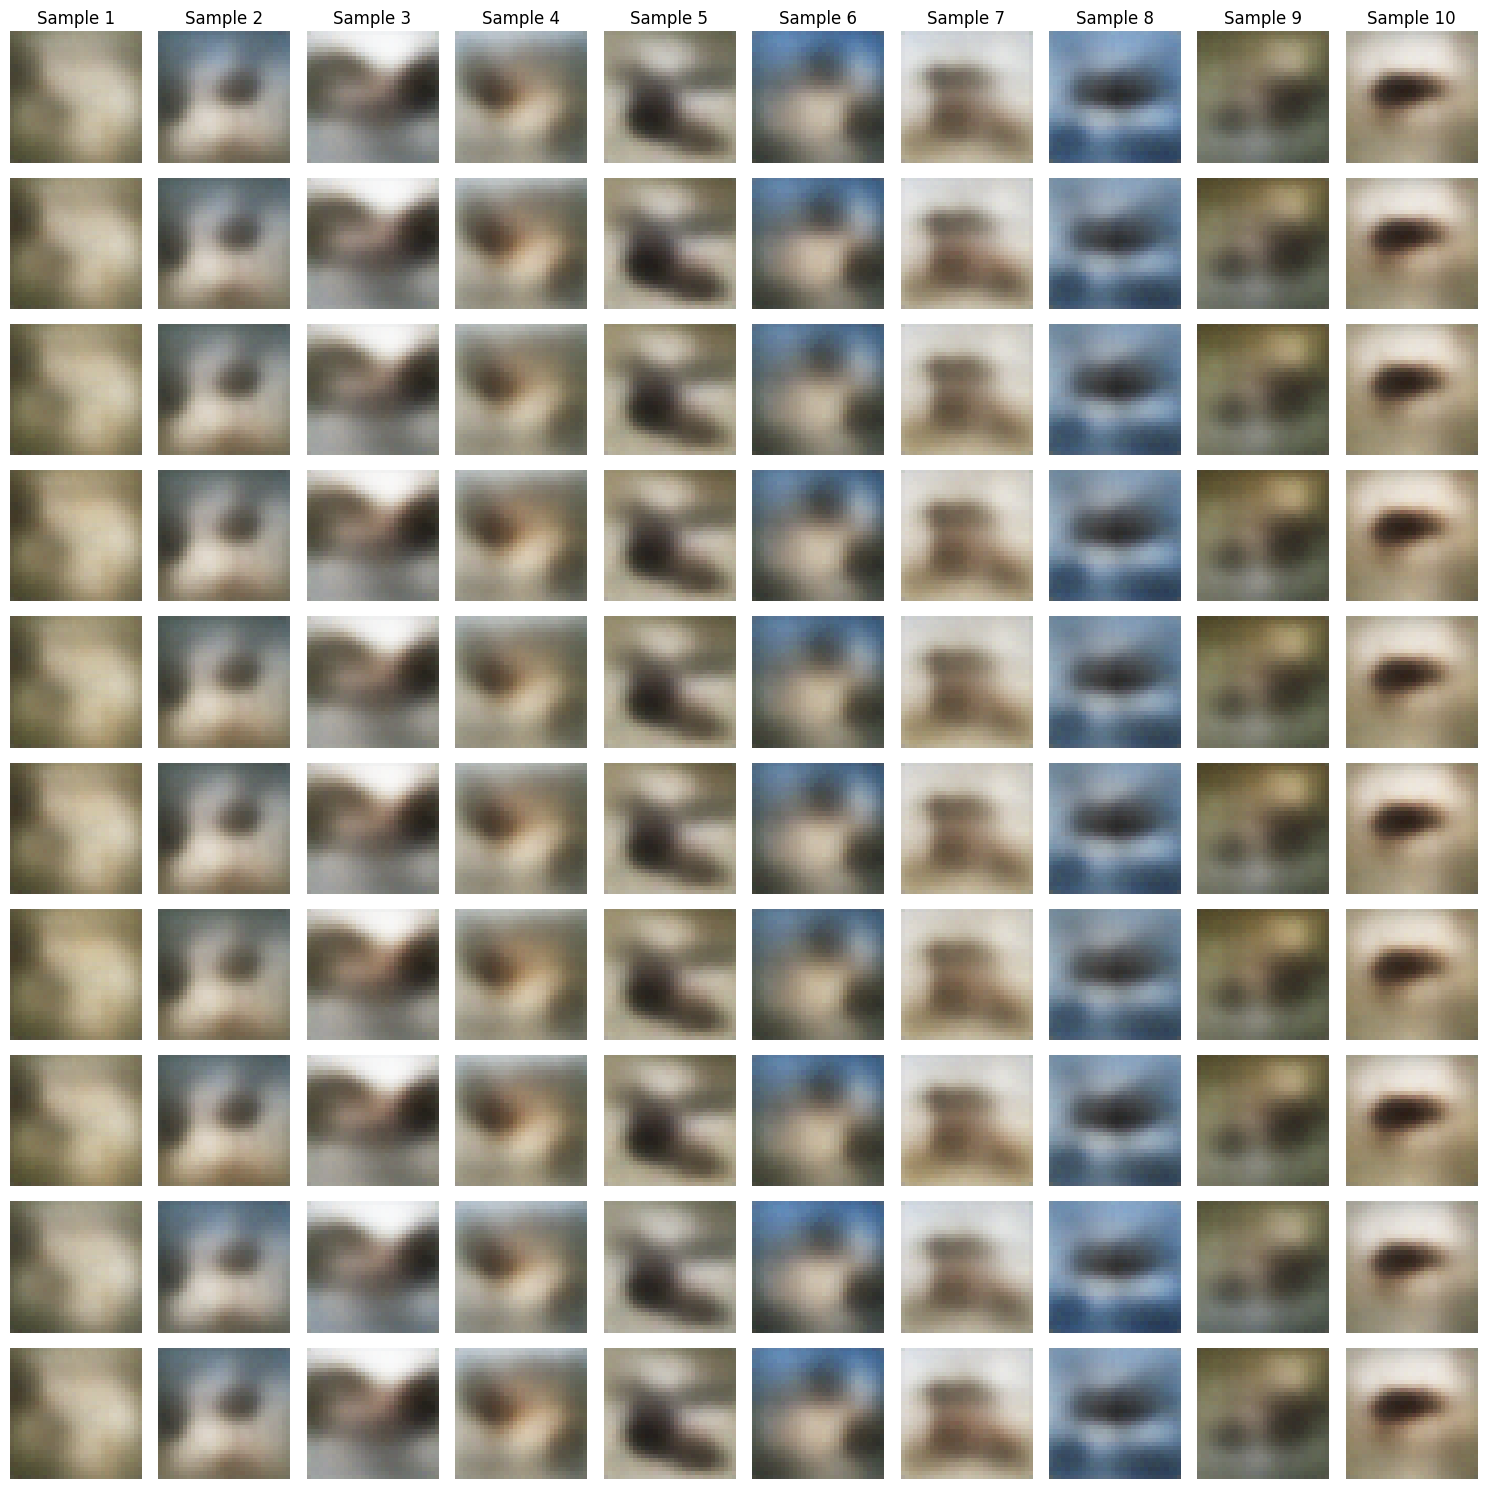

In [11]:
print(f"Loading best model from epoch {best_epoch}")
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Generate samples for each class
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
              'dog', 'frog', 'horse', 'ship', 'truck']

# Create a demonstration of the class conditioning
plt.figure(figsize=(15, 15))
samples_per_class = 10

# Generate samples for all classes using the same latent vectors
with torch.no_grad():
    # Create 10 fixed latent vectors
    fixed_z = torch.randn(samples_per_class, latent_dim).to(device)
    
    # For each class, generate images using the same latent vectors
    all_samples = []
    for class_idx in range(num_classes):
        # Create labels for this class
        labels = torch.full((samples_per_class,), class_idx).to(device)
        c_one_hot = F.one_hot(labels, num_classes=num_classes).float()
        
        # Generate samples
        samples = model.decode(fixed_z, c_one_hot).cpu()
        all_samples.append(samples)
    
    # Reshape for display: [num_classes, samples_per_class, channels, height, width]
    all_samples = torch.stack(all_samples)

# Display the samples
fig, axes = plt.subplots(num_classes, samples_per_class, figsize=(15, 15))
for i in range(num_classes):
    for j in range(samples_per_class):
        ax = axes[i, j]
        ax.imshow(all_samples[i, j].permute(1, 2, 0).numpy())
        if j == 0:  # Add class label on the left
            ax.set_ylabel(class_names[i], fontsize=12)
        ax.axis('off')
        
        if i == 0:  # Add sample number at the top
            ax.set_title(f"Sample {j+1}")

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/cvae_class_controlled_samples.png')
plt.show()

## CVAE与标准VAE的比较

条件变分自编码器（CVAE）是标准变分自编码器（VAE）的扩展，通过引入条件信息实现了对生成过程的控制。二者的主要区别如下：

### 数学模型差异

1. **目标函数**：
   - **标准VAE**：最大化对数似然 $\log p(x)$ 的证据下界
   - **CVAE**：最大化条件对数似然 $\log p(x|y)$ 的证据下界

2. **编码过程**：
   - **标准VAE**：编码器参数化 $q_\phi(z|x)$
   - **CVAE**：编码器参数化 $q_\phi(z|x,y)$，同时考虑输入和条件

3. **解码过程**：
   - **标准VAE**：解码器参数化 $p_\theta(x|z)$
   - **CVAE**：解码器参数化 $p_\theta(x|z,y)$，同时使用潜在变量和条件

### 实现结构差异

1. **网络架构**：
   - **标准VAE**：编码器输入为图像，解码器输出为图像
   - **CVAE**：编码器输入为图像和类别标签，解码器输入为潜在向量和类别标签

2. **条件信息融合**：
   - CVAE需要将条件信息（如类别标签）融入网络
   - 常用方法包括连接（concatenation）、条件归一化、FiLM层等

### 功能差异

1. **生成控制**：
   - **标准VAE**：只能通过调整潜在向量控制生成结果
   - **CVAE**：可以固定潜在向量，通过改变条件信息控制生成属性

2. **表征学习**：
   - **标准VAE**：潜在空间包含所有变化因素（如类别、风格等）
   - **CVAE**：潜在空间可以更专注于条件无关的变化因素（如风格、姿态）

3. **插值能力**：
   - **CVAE**：能够在固定条件下进行潜在空间插值，或在固定潜在向量下进行条件插值

通过这些对比，我们可以看出CVAE在保留VAE概率生成能力的同时，增加了对生成过程的条件控制，使生成结果更可控、更有针对性，特别适合于需要生成特定类别或属性内容的应用场景。

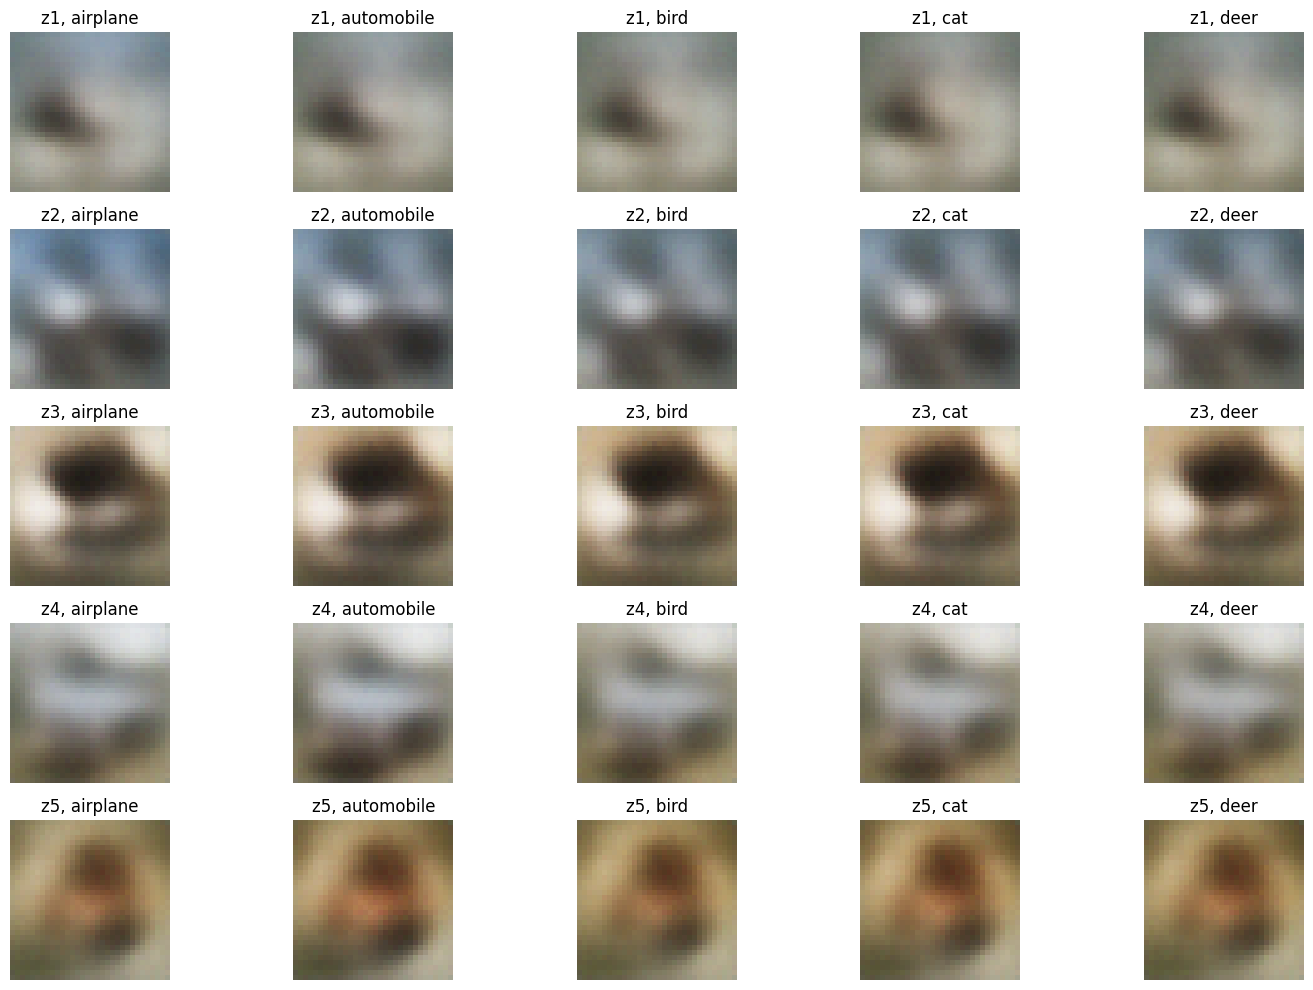

In [ ]:
class ModifiedCVAE(nn.Module):
    def __init__(self, original_cvae):
        super(ModifiedCVAE, self).__init__()
        # Copy the original CVAE
        self.original_cvae = original_cvae
        
    def forward(self, z):
        """Generate images using latent vectors without class conditioning"""
        # Use a default "placeholder" class (e.g., class 0)
        batch_size = z.size(0)
        placeholder_labels = torch.zeros(batch_size, dtype=torch.long).to(z.device)
        c_one_hot = F.one_hot(placeholder_labels, num_classes=self.original_cvae.num_classes).float()
        
        # Decode using the original CVAE's decoder
        return self.original_cvae.decode(z, c_one_hot)

# Create the modified CVAE
modified_cvae = ModifiedCVAE(model).to(device)

# Generate a comparative visualization
plt.figure(figsize=(15, 10))

# Generate samples using fixed noise but different class labels
with torch.no_grad():
    # Create fixed latent vectors
    fixed_z = torch.randn(5, latent_dim).to(device)
    
    # Generate 5 different class examples
    comparison_classes = [0, 1, 2, 3, 4]  # airplane, automobile, bird, cat, deer
    
    # For each latent vector
    for z_idx in range(5):
        # Generate with different class labels
        for c_idx, class_idx in enumerate(comparison_classes):
            # Generate the sample
            labels = torch.tensor([class_idx], device=device)
            c_one_hot = F.one_hot(labels, num_classes=num_classes).float()
            sample = model.decode(fixed_z[z_idx:z_idx+1], c_one_hot).cpu()
            
            # Plot
            plt.subplot(5, 5, z_idx * 5 + c_idx + 1)
            plt.imshow(sample[0].permute(1, 2, 0).numpy())
            plt.title(f"z{z_idx+1}, {class_names[class_idx]}")
            plt.axis('off')

plt.tight_layout()
plt.savefig(f'{RESULT_SAVE_PATH}/cvae_comparison.png')
plt.show()

## 类别控制生成与评估

条件变分自编码器（CVAE）最显著的特点是能够通过条件信息控制生成内容。在本实现中，我们展示了两种关键的评估方式：

### 类别条件生成

通过为不同的随机潜在向量分配相同的类别标签，我们可以生成属于特定类别的多样化样本。这种生成方式展示了模型在保持类别一致性的同时，能够捕捉类内变化（如不同姿态、颜色变化等）。

具体而言，对于每个类别：
- 生成10个不同的随机潜在向量
- 为这些向量分配相同的类别标签
- 观察生成图像是否符合指定类别，同时保持多样性

### 潜在空间与条件的交互

通过固定相同的潜在向量，但分配不同的类别标签，我们可以观察条件信息如何影响生成内容。这种评估方法展示了：

1. **潜在空间语义**：潜在向量捕捉了类别无关的特征（如样式、背景等）
2. **条件控制能力**：条件信息可以有效引导生成特定类别的内容
3. **语义一致性**：相同潜在向量在不同条件下生成的图像保持某种语义联系

通过这些评估，我们可以验证CVAE是否成功学习了条件数据分布，并能够根据指定条件生成相应内容，同时保持潜在空间的有意义结构。这种能力对于可控图像生成、图像编辑和风格迁移等应用非常重要。

# 条件变分自编码器总结与进阶方向

本实现展示了一个基于深度卷积网络的条件变分自编码器（CVAE），应用于CIFAR-10图像数据集的类别条件生成任务。通过引入类别条件，模型能够生成指定类别的图像，同时保持潜在空间的结构化特性。

## 关键技术要点

- **条件信息融合**：通过连接（concatenation）方式将类别信息融入编码器和解码器
- **KL退火策略**：gradually增加KL散度权重，平衡重建质量和潜在空间约束
- **深度卷积结构**：使用卷积/反卷积层处理图像数据，提高生成质量
- **条件控制评估**：通过类别条件生成和潜在向量固定实验展示模型的能力

## 可能的改进方向

1. **架构改进**：
   - 实现层次化CVAE（HCVAE）增强表达能力
   - 引入注意力机制捕捉更细致的特征依赖
   - 尝试扩散模型（Diffusion Models）改进生成质量

2. **条件控制增强**：
   - 扩展到多条件控制（类别+属性+风格）
   - 实现条件解耦（如通过InfoVAE或β-TCVAE）
   - 添加文本条件，实现文本-图像生成

3. **训练策略优化**：
   - 尝试更复杂的KL退火策略（如循环退火）
   - 实现对抗训练来改善生成质量（VAE-GAN）
   - 添加知识蒸馏从预训练模型中学习

4. **应用扩展**：
   - 实现图像转换（如素描到彩色）
   - 开发风格迁移功能
   - 构建图像编辑和属性操作接口

CVAE结合了变分推断的概率框架和条件生成的控制能力，为生成模型领域提供了强大工具。通过进一步探索和改进，可以应用于图像合成、数据增强、异常检测等多种场景，并与其他生成模型（如GAN和扩散模型）互补配合。